In [2]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cooler
import bioframe
import cooltools
from cooltools.lib import plotting
import cooler as clr
import h5py
import coolbox
from coolbox.api import *
from coolbox.utilities import GenomeRange
from pygenometracks import readBed, readGtf
from pygenometracks.tracks import BedTrack

import glob
from pathlib import Path
import re

warnings.filterwarnings("ignore")

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

In [3]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12

plt.rcParams.update({
    "text.usetex": False})

# makes illustrator recognize text as text objects
plt.rc('pdf',fonttype = 42) 

In [4]:
def cat_prefix_to_list(prefix, file_list):
    """
    Helper function that concatenates a prefix to every element
    in a list. 
    """
    return [os.path.join(prefix, file) for file in file_list]

def make_region_plot(region, resolution, highlight_region_list, microc_file, microc_title,
                     chip_list_list, forward_proseq_list, reverse_proseq_list, condition_order, 
                     bigwig_bins=3600, highlight_buffer=1000, pro_bins=None):
    
    """
    Function that makes a plot of a region with Micro-C, ChIP-seq, and Pro-seq.
    
    region: (str) string that specifies region for plotting.
    resolution: (int) resolution of micro-c map used
    highlight_region_list: List of regions of format [chr, start, end] to highlight
    microc_file: (str) file path to micro-c data
    microc_title: (str) title for micro-c
    chip_list_list: List of lists containing paths to bigwigs
    forward_proseq_list: List of paths to forward strand pro-seq files
    reverse_proseq_list: List of paths to reverse strand pro-seq files
    condition_order: List indicating order of conditions to plot. 
    """
    
    heatmap = Cool(microc_file, resolution=resolution, **MICROC_PLOTTING_PARAMS) + Title(microc_title)
    frame = heatmap
    if pro_bins is None:
        pro_bins = bigwig_bins
    def iterate_over_datasets(frame):
        i = 0 
        for chip_list in chip_list_list:
            bigwig_list = make_bigwig_list(chip_list, region, condition_order, 
                                           DEFAULT_COLOR_LIST[i%len(DEFAULT_COLOR_LIST)], bw_bins=bigwig_bins)
            i += 1
            for bigwig in bigwig_list:
                frame += bigwig + Spacer(SPACER_HEIGHT)
        f_bigwig_list = make_bigwig_list(forward_proseq_list, region, condition_order, 
                                       DEFAULT_COLOR_LIST[i%len(DEFAULT_COLOR_LIST)], bw_bins=pro_bins,  
                                         track_height=PRO_SEQ_TRACK_HEIGHT)
        r_bigwig_list = make_bigwig_list(reverse_proseq_list, region, len(reverse_proseq_list)*[""], 
                               DEFAULT_COLOR_LIST[(i+1)%len(DEFAULT_COLOR_LIST)], bw_bins=pro_bins, 
                                         track_height=PRO_SEQ_TRACK_HEIGHT)
        r_bigwig_list = [r_bigwig + Inverted() for r_bigwig in r_bigwig_list]
        for f_bigwig, r_bigwig in zip(f_bigwig_list, r_bigwig_list):
                frame += f_bigwig + r_bigwig + Spacer(SPACER_HEIGHT)
        annotations = NewBed(*ANNOTATIONS_PARAMS)
        frame += annotations
        return frame
    
    # check if it needs a highlight
    if len(highlight_region_list) > 0:
        highlight_regions = []
        for highlight_region in highlight_region_list:
            highlight_region[1] -= highlight_buffer
            highlight_region[2] += highlight_buffer 
            highlight_regions.append(tuple(highlight_region))

        highlights = HighLights(highlight_regions, **HIGHLIGHT_PARAMS)
        with highlights:
            frame = iterate_over_datasets(frame)
    else:
        frame = iterate_over_datasets(frame)
    #frame += XAxis()
    return frame

def make_region_plot_mod(region, resolution, microc_file,
                     bw_list, condition_order, gene_annot_name, bedgraph_fname=None, plot_variants=False,
                     file_bottom=None, cmap_chip='tab10', bigwig_bins=1600, autoscale=True, plot_bed=False,
                        variant_track_height=2, custom_valranges=None, plot_genes=True):
    
    """
    Function that makes a plot of a region with Micro-C, ChIP-seq, and Pro-seq.
    
    region: (str) string that specifies region for plotting.
    resolution: (int) resolution of micro-c map used
    highlight_region_list: List of regions of format [chr, start, end] to highlight
    microc_file: (str) file path to micro-c data
    microc_title: (str) title for micro-c
    chip_list_list: List of lists containing paths to bigwigs
    forward_proseq_list: List of paths to forward strand pro-seq files
    reverse_proseq_list: List of paths to reverse strand pro-seq files
    condition_order: List indicating order of conditions to plot. 
    """
    print(region, resolution, microc_file)
    heatmap = Cool(microc_file, file_bottom=file_bottom, resolution=resolution, **MICROC_PLOTTING_PARAMS) 
    frame = heatmap + Spacer(SPACER_HEIGHT*3)
    if plot_bed:
        frame+=NewBed(*BED_PARAMS) + TrackHeight(3) + Spacer(SPACER_HEIGHT)
    #frame +=  BED(finemapped_variant_name, border_only=True, 
    #              alpha=0.1, show_score='yes', linewidth=0.5, display="collapsed", height=1, edgecolor="#0099BB") + Spacer(SPACER_HEIGHT)
    if len(bw_list)>0:
        bigwig_list = make_bigwig_list(bw_list, region, condition_order, autoscale=False)
        cmap_arr = sns.color_palette(cmap_chip, n_colors=len(bigwig_list))

        for i, bigwig in enumerate(bigwig_list):
            if autoscale:
                frame += auto_scale_bigwig(bigwig, region) + Color(cmap_arr[i]) + Spacer(SPACER_HEIGHT)
            else:
                frame += bigwig + MaxValue(custom_valranges[i]) + MinValue(0) + Color(cmap_arr[i]) + Spacer(SPACER_HEIGHT)

    if bedgraph_fname is not None:
        frame += BedGraph(bedgraph_fname) + Title("HbF_Base") + Color("#EE7733") + MaxValue(100) + MinValue(0)+ Spacer(SPACER_HEIGHT)
    
    if plot_variants:
        frame+=SNP(finemapped_variant_name, **VARIANTS_PARAMS) \
        + HLines(0, line_width=2, line_style='-',color='k') + Title("HbF GWAS [-log10(p)]")  + TrackHeight(variant_track_height) + Spacer(SPACER_HEIGHT)
    
    if plot_genes:
        annotations = NewBed(*GTF_PARAMS)
#     annotations = GTF(gene_annot_name, color=["#000000"], gene_rows=1, 
#                       filter_named_genes=True, row_filter=None) 
        frame+=annotations

    return frame

def auto_scale_bigwig(bigwig_single, region, y_max=None, y_min=0):
    """
    Autoscales y axis of bigwigs in bigwig list based off values in `region`.
    """
    def get_max_y_value(bigwig_single, region):
        return np.round(np.amax(bigwig_single.fetch_plot_data(GenomeRange(region))))
    
    if y_max is None:
        if type(region) == list:
            y_max_list = [get_max_y_value(bigwig_single, single_region) for single_region in region]
            y_max = max(y_max_list)
        else:
            y_max = get_max_y_value(bigwig_single, region)
    
    return bigwig_single + MaxValue(y_max) + MinValue(y_min)
            
def auto_scale_bigwigs(bigwig_list, region, y_max=None, y_min=0):
    """
    Autoscales y axis of bigwigs in bigwig list based off values in `region`.
    """
    def get_max_y_value(bigwig_list, region):
        max_y_values = []
        for bigwig in bigwig_list:
            max_y_values.append(np.amax(bigwig.fetch_plot_data(GenomeRange(region))))

        y_max = round(max(max_y_values) * 1.05)
        return y_max
    
    if y_max is None:
        if type(region) == list:
            y_max_list = [get_max_y_value(bigwig_list, single_region) for single_region in region]
            y_max = max(y_max_list)
        else:
            y_max = get_max_y_value(bigwig_list, region)
                
    return [bigwig + MaxValue(y_max) + MinValue(y_min) for bigwig in bigwig_list]

def read_cooler(cooler_path, resolution=250):
    """
    Simple function wrapper to read cooler file at a particular resolution.
    """
    if clr.fileops.is_cooler(cooler_path):
        return clr.Cooler(cooler_path)
    elif clr.fileops.is_multires_file(cooler_path):
        return clr.Cooler(cooler_path + "::resolutions/" + str(int(resolution)))

# define new bed format
class NewBed(Track):
    """
    Custom pygenometracks class that allows for control over the aesthetics of gene annotations in
    region plots. 
    """
    def __init__(self, coolbox_prop_dict, pygenometracks_prop_dict):
        super().__init__(coolbox_prop_dict)  # init 
        self.pygenometracks_object = BedTrack(pygenometracks_prop_dict)

    def fetch_data(self, gr, **kwargs):
        pass

    def plot(self, ax, gr, **kwargs):
#         x = gr.start + self.properties['offset'] * (gr.end - gr.start)
#         ax.text(x, 0, gr.chrom, fontsize=self.properties['fontsize'])
#         ax.set_xlim(gr.start, gr.end)
        self.pygenometracks_object.plot(ax, gr.chrom, gr.start, gr.end)
        ax.set_xlim([gr.start, gr.end])

In [5]:
# Differential map 

class HiCDiff2(HicMatBase):
    """
    Track for express the comparison between two HiC Track.

    Parameters
    ----------
    hic1 : coolbox.api.track.Cool
        First HiC Track or hic file path(.cool, .mcool, .hic).

    hic2 : coolbox.api.track.Cool
        Second HiC Track or hic file path(.cool, .mcool, .hic).

    args_hic: dict
        Key word arguments send to create Cool/DoctHic instance if the input hic1/hic2 is file.

    diff_method : str
        Difference method ('diff', 'log2fc'), default 'diff'


    """

    DEFAULT_ARGS_HIC = {
        "transform": "no",
        "normalize": "expect",
        "gaussian_sigma": "no",
        "process_func": "no",
    }

    DEFAULT_PROPERTIES = {
        'style': HicMatBase.STYLE_WINDOW,
        "cmap": "bwr",
        "transform": False,
        'diff_method': "diff",
        'args_hic': DEFAULT_ARGS_HIC,
    }

    def __init__(self, hic1, hic2, **kwargs):
        properties = HiCDiff.DEFAULT_PROPERTIES.copy()
       
        properties.update(kwargs)
        
        super().__init__(**properties)

        # TODO how to set hic_args in cli mode ?
        if isinstance(hic1, str):
            hic1 = HiCMat(hic1)
        if isinstance(hic2, str):
            hic2 = HiCMat(hic2)
        self.properties.update({
            'hic1': hic1,
            'hic2': hic2,
        })

        self.mat1 = None
        self.mat2 = None

    def fetch_data(self, gr: GenomeRange, **kwargs) -> np.ndarray:
        # TODO find a better way
        # For cases when updating of Frame's depth_ratio leads to un equal matrix sizes for different tracks).
        args_hic = self.properties.copy()
        args_hic.update(self.properties.get('args_hic', {}))
        for hic in ('hic1', 'hic2'):
            self.properties[hic].properties.update(args_hic)

        hic1: HicMatBase = self.properties['hic1']
        hic2: HicMatBase = self.properties['hic2']
        # must set to avoid re-change GenomeRange in window style
        kwargs['gr_updated'] = True
        # use transformed gr for cases in 'window' style, other wise the gr would be transformed two times
        self.mat1 = mat1 = hic1.fetch_data(gr)
        self.mat2 = mat2 = hic2.fetch_data(gr)
        diff_mat = self.diff_matrix(mat1, mat2)
        try:
            self.SMALL_VALUE = diff_mat[diff_mat > 0].min()
        except Exception:
            pass
        return diff_mat

    def diff_matrix(self, mat1, mat2):
        diff_mth = self.properties['diff_method']
        if diff_mth == 'log2fc':
            return np.log2(mat1) - np.log2(mat2)
        else:
            return mat1# - mat2

In [6]:
# convenience function for varsh's dataset (others do not need)
def get_locus_from_coord(row, flank):
    return f"{row['chr']}:{int(row['coord'])-flank}-{int(row['coord'])+flank}"

In [7]:
def make_bigwig_list(bigwigs, region, condition_order, bw_bins=1600, track_height=2, autoscale=True, 
                     y_max=None):
    
    """
    Helper function for `make_region_plot` that converts file paths to bigwig plotting objects.
    """
    assert len(bigwigs) % len(condition_order) == 0
    bigwig_list = [BigWig(bigwig, number_of_bins=bw_bins) + Title(title) \
                            + TrackHeight(2) for bigwig, title in zip(bigwigs, condition_order)]
    if autoscale:
        bigwig_list = auto_scale_bigwigs(bigwig_list, region, y_max=y_max)
    return bigwig_list

In [8]:
class ChromName(Track):
    """
    Track for show chromosome name.

    Parameters
    ----------
    fontsize : float
        Font name to show.

    offset : float
        Offset ratio to the start position.
    """

    DEFAULT_PROPERTIES = {
        "fontsize": 50,
        "offset": 0.45,
    }

    def __init__(self, **kwargs):
        properties = ChromName.DEFAULT_PROPERTIES.copy()
        properties.update(kwargs)
        super().__init__(properties)

    def fetch_data(self, gr: GenomeRange, **kwargs):
        return gr.chrom  # return chromosome name

    def plot(self, ax, gr: GenomeRange, **kwargs):
        x = gr.start + self.properties['offset'] * (gr.end - gr.start)
        ax.text(x, 0, gr.chrom, fontsize=self.properties['fontsize'])
        ax.set_xlim(gr.start, gr.end)


In [9]:
# define the bigwig and RNAseq files 
# this will have to be completely hardcoded 

base_dir = '/mnt/coldstorage/Varshmallow/'
cohesin_rnaseq_dir = '/mnt/md1/varshini/Blood/rnaseq/aligned'


def get_chip_list(base_dir='/mnt/coldstorage/Varshmallow/', phase=1, phase2=None, 
                  include=['RNASeq', 'ATAC', 'H3K27ac', 'H3K4me1']):

    chip_dict = {}
    chip_dict[f'RNASeq_P{phase}'] = f'{base_dir}Blood_RNAseq/Phase{phase}_RNA_chr.bw'
    
    # ATAC-Seq
    chip_dict[f'ATAC_P{phase}'] = f'{base_dir}Blood_ATAC/Phase{phase}_ATAC.bw'
    
    chip_dict['NIPBL'] = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/bigwigs/GSM8864683_HUDEP-2_NIPBL_rep1_2_mean.bw'
 
    chip_dict['STAG1_C2'] = os.path.join(cohesin_rnaseq_dir, "STAG1_C2_G1_rmdup_CPM.bw")
    chip_dict['STAG1_C3'] = os.path.join(cohesin_rnaseq_dir, "STAG1_C3_G1_rmdup_CPM.bw")
    chip_dict['STAG2_C2'] = os.path.join(cohesin_rnaseq_dir, "STAG2_C2_G2_rmdup_CPM.bw")
    chip_dict['STAG2_C3'] = os.path.join(cohesin_rnaseq_dir, "STAG2_C3_G2_rmdup_CPM.bw")
    chip_dict['NIPBL_C3'] = os.path.join(cohesin_rnaseq_dir, "NIPBL_C3_G1_rmdup_CPM.bw")
    chip_dict['NIPBL_C2'] = os.path.join(cohesin_rnaseq_dir, "NIPBL_C2_G1_rmdup_CPM.bw")
    chip_dict['AAVS1_C2'] = os.path.join(cohesin_rnaseq_dir, "AAVS1_C2_G1_rmdup_CPM.bw")
    chip_dict['AAVS1_C3'] = os.path.join(cohesin_rnaseq_dir, "AAVS1_C3_G1_rmdup_CPM.bw")
    
    
    if phase2 is not None:
        chip_dict[f'ATAC_P{phase2}'] = f'{base_dir}Blood_ATAC/Phase{phase2}_ATAC.bw'
        chip_dict[f'RNASeq_P{phase2}'] = f'{base_dir}Blood_RNAseq/Phase{phase2}_RNA_chr.bw'
        
    # Histone ChIP
    chip_dir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/bigwigs/'

    directory = os.fsencode(chip_dir)
    
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        rm = re.match(rf'\w*P{phase}_CTCF\S*', filename)
        if rm is not None:
            chip_dict[f'CTCF_P{phase}'] = f'{chip_dir}{rm.group(0)}'

        rm = re.match(rf'\w*P{phase}_H3K27ac\S*', filename)
        if rm is not None:
            chip_dict[f'H3K27ac_P{phase}']  = f'{chip_dir}{rm.group(0)}'

        rm = re.match(rf'\w*P{phase}_H3K4me1\S*', filename)
        if rm is not None:
            chip_dict[f'H3K4me1_P{phase}'] = f'{chip_dir}{rm.group(0)}'
       
        rm = re.match(r'\w*GATA1\S*', filename)
        if rm is not None:
            chip_dict[f'GATA1'] = f'{base_dir}Blood_ChIP/P{phase}/{rm.group(0)}'
            
        
    if phase2 is not None:
        for file in os.listdir(directory):
            filename = os.fsdecode(file)
            rm = re.match(rf'\w*P{phase2}_CTCF\S*', filename)
            if rm is not None:
                chip_dict[f'CTCF_P{phase2}'] = f'{chip_dir}{rm.group(0)}'

            rm = re.match(rf'\w*P{phase2}_H3K27ac\S*', filename)
            if rm is not None:
                chip_dict[f'H3K27ac_P{phase2}']  = f'{chip_dir}{rm.group(0)}'

            rm = re.match(rf'\w*P{phase2}_H3K4me1\S*', filename)
            if rm is not None:
                chip_dict[f'H3K4me1_P{phase2}'] = f'{chip_dir}{rm.group(0)}'

        
    chip_list = [chip_dict[key] for key in include]
    return chip_list

In [10]:
from itertools import product

conds = ['AAVS1','STAG1','STAG2', 'NIPBL']
reps = ['C2', 'C3']

guides = {'AAVS1':'G1', 'STAG1':'G1', 'STAG2':'G2', 'NIPBL':'G1'}

uc_path = '/mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep'
uc_expected_path = '/mnt/md0/varshini/Analysis/Blood/microc_expected'

resolution = 5000
uc_filenames = [os.path.join(uc_path, f'{cond}_{rep}_{guides[cond]}_all.250.mcool') for cond, rep in product(conds, reps)]

savedir=None

In [11]:
# Domenic
GTF_FILENAME = "/mnt/md0/varshini/Gene_Annotations/refSeqSelect.bed"

# Define plotting aesthetics as global variables
HIGHLIGHT_PARAMS = {"color":"gray",
                   "alpha":0.5,
                   "border_line":False}

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-0.5,
                          "min_value":-4.5}


SPACER_HEIGHT = 0.4
DEFAULT_COLOR_LIST = ["#FF0000", "#00FA00", "#0000FF", "#A0F000"]
PRO_SEQ_TRACK_HEIGHT = 1.2


GTF_PARAMS = [
     {"height":2},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    #"gene_rows":1,
    "merge_transcripts":True,       #"gene_style":"normal",
    "border_only":"true",
     "color": "#000000"
    }] # PATH TO BED FILE OF GENE ANNOTATIONS


regions = {
    'reg1':'chr6:110261637-110661637',
    'reg2':'chr10:119332263-119732263',
    'reg3':'chr12:12827336-13227336',
    'reg4':'chr9:135730974-136130974',
    'reg5':'chr17:49588253-49958253',
    'reg6':'chr20:50703609-51103609',
    'reg7':'chr5:171063501-171463501',
    'reg8':'chr6:75432929-75832929',
    'reg9':'chr22:42967519-43367519',
    'reg10':'chr13:32551817-32951817',
    'reg11':'chr12:12861571-13261571',
    'reg12':'chr7:27992941-28392941',
    'reg13':'chr17:67584439-67984439',
    'reg14':'chr5:171063501-171463501',
    'reg15':'chr22:19219097-19619097',
    'reg16':'chr17:44092492-44492492',
    'tmcc2': 'chr1:205027912-205485632',
    'rrad':'chr16:66721682-67126308',
    'timp3':'chr22:32,601,576-33,063,042',
    'hmox1':'chr22:35,180,361-35,594,214',
    'stk32b':'chr4:4,819,386-5,700,994',
    'cobll1':'chr2:164,453,624-165,043,679',
    'serpinh1':'chr11:75,461,564-75,772,787',
    'mgll':'chr3:127,489,062-128,252,190'
}

regions_stag2 = {
    'reg1':'chr18:57769848-58469848',
    'reg2':'chr22:30148801-30548801',
    'reg3':'chr18:62206436-62806436',
    'anxa1':'chr9:72,948,874-73,370,629',
    'cxcl8':'chr4:73,540,519-73,947,379',
    'slco2b1':'chr11:74,900,563-75,306,549',
    'cdkn1a':'chr6:36,476,441-36,887,397',
    'tpm4':'chr19:15,67,021-16,303,011',
    'bcl11a':'chr2:60304475-60646280'
}

# klf1: -0.5 to -4.5
# hbb: -1.25 to -4.25

tf_acrs_name = '/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/erythroid_tf_acrs_unique.bed'

BED_PARAMS = [{"height":1},
                      {"file": tf_acrs_name,
                      "max_labels":1,
                       "gene_rows":1,
                      "border_only":"true"}]


In [12]:
uc_filenames

['/mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C2_G1_all.250.mcool',
 '/mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C3_G1_all.250.mcool',
 '/mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/STAG1_C2_G1_all.250.mcool',
 '/mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/STAG1_C3_G1_all.250.mcool',
 '/mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/STAG2_C2_G2_all.250.mcool',
 '/mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/STAG2_C3_G2_all.250.mcool',
 '/mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/NIPBL_C2_G1_all.250.mcool',
 '/mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/NIPBL_C3_G1_all.250.mcool']

In [13]:
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v1/figure5"


mm="/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed"
from matplotlib.backends.backend_pdf import PdfPages

top_match = pd.read_csv(mm, sep='\t').sort_values(by='triangle_score_P3', ascending=False)
top_match = top_match[top_match['quant']==3].reset_index()


def get_locus_from_coord(row, flank=200_000):
    return f"{row['chr']}:{int(row['coord'])-flank}-{int(row['coord'])+flank}"

regions = top_match.apply(get_locus_from_coord, axis=1)

incl= ['H3K27ac_P2','H3K4me1_P2', 'CTCF_P2','RNASeq_P2','RNASeq_P3', 'ATAC_P3']

GTF_PARAMS = [
     {"height":4},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    #"gene_rows":1,
    "merge_transcripts":True,       #"gene_style":"normal",
    "border_only":"true",
     "color":"#000000"
    }] # PATH TO BED FILE OF GENE ANNOTATIONS

chip_list = get_chip_list(include=incl, phase=2, phase2=3)
with PdfPages(os.path.join(savedir, 'c4_match_nipbl.pdf')) as pdf:
     for i in range(50):
        region_str = regions[i]
        plt.figure()
        try:
            frame = make_region_plot_mod(region_str, resolution, uc_filenames[1],
                             chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                            bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                             file_bottom = uc_filenames[7], cmap_chip="deep", autoscale=True, plot_bed=False,
                                plot_genes=True)
            fig = frame.plot(region_str)
        except ValueError:
            continue
        pdf.savefig(fig)
        plt.close()


In [14]:
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v4/supp14"

if not os.path.exists(savedir):
    os.mkdir(savedir)

chr17:49588253-49958253 5000 /mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C3_G1_all.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33358.30it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


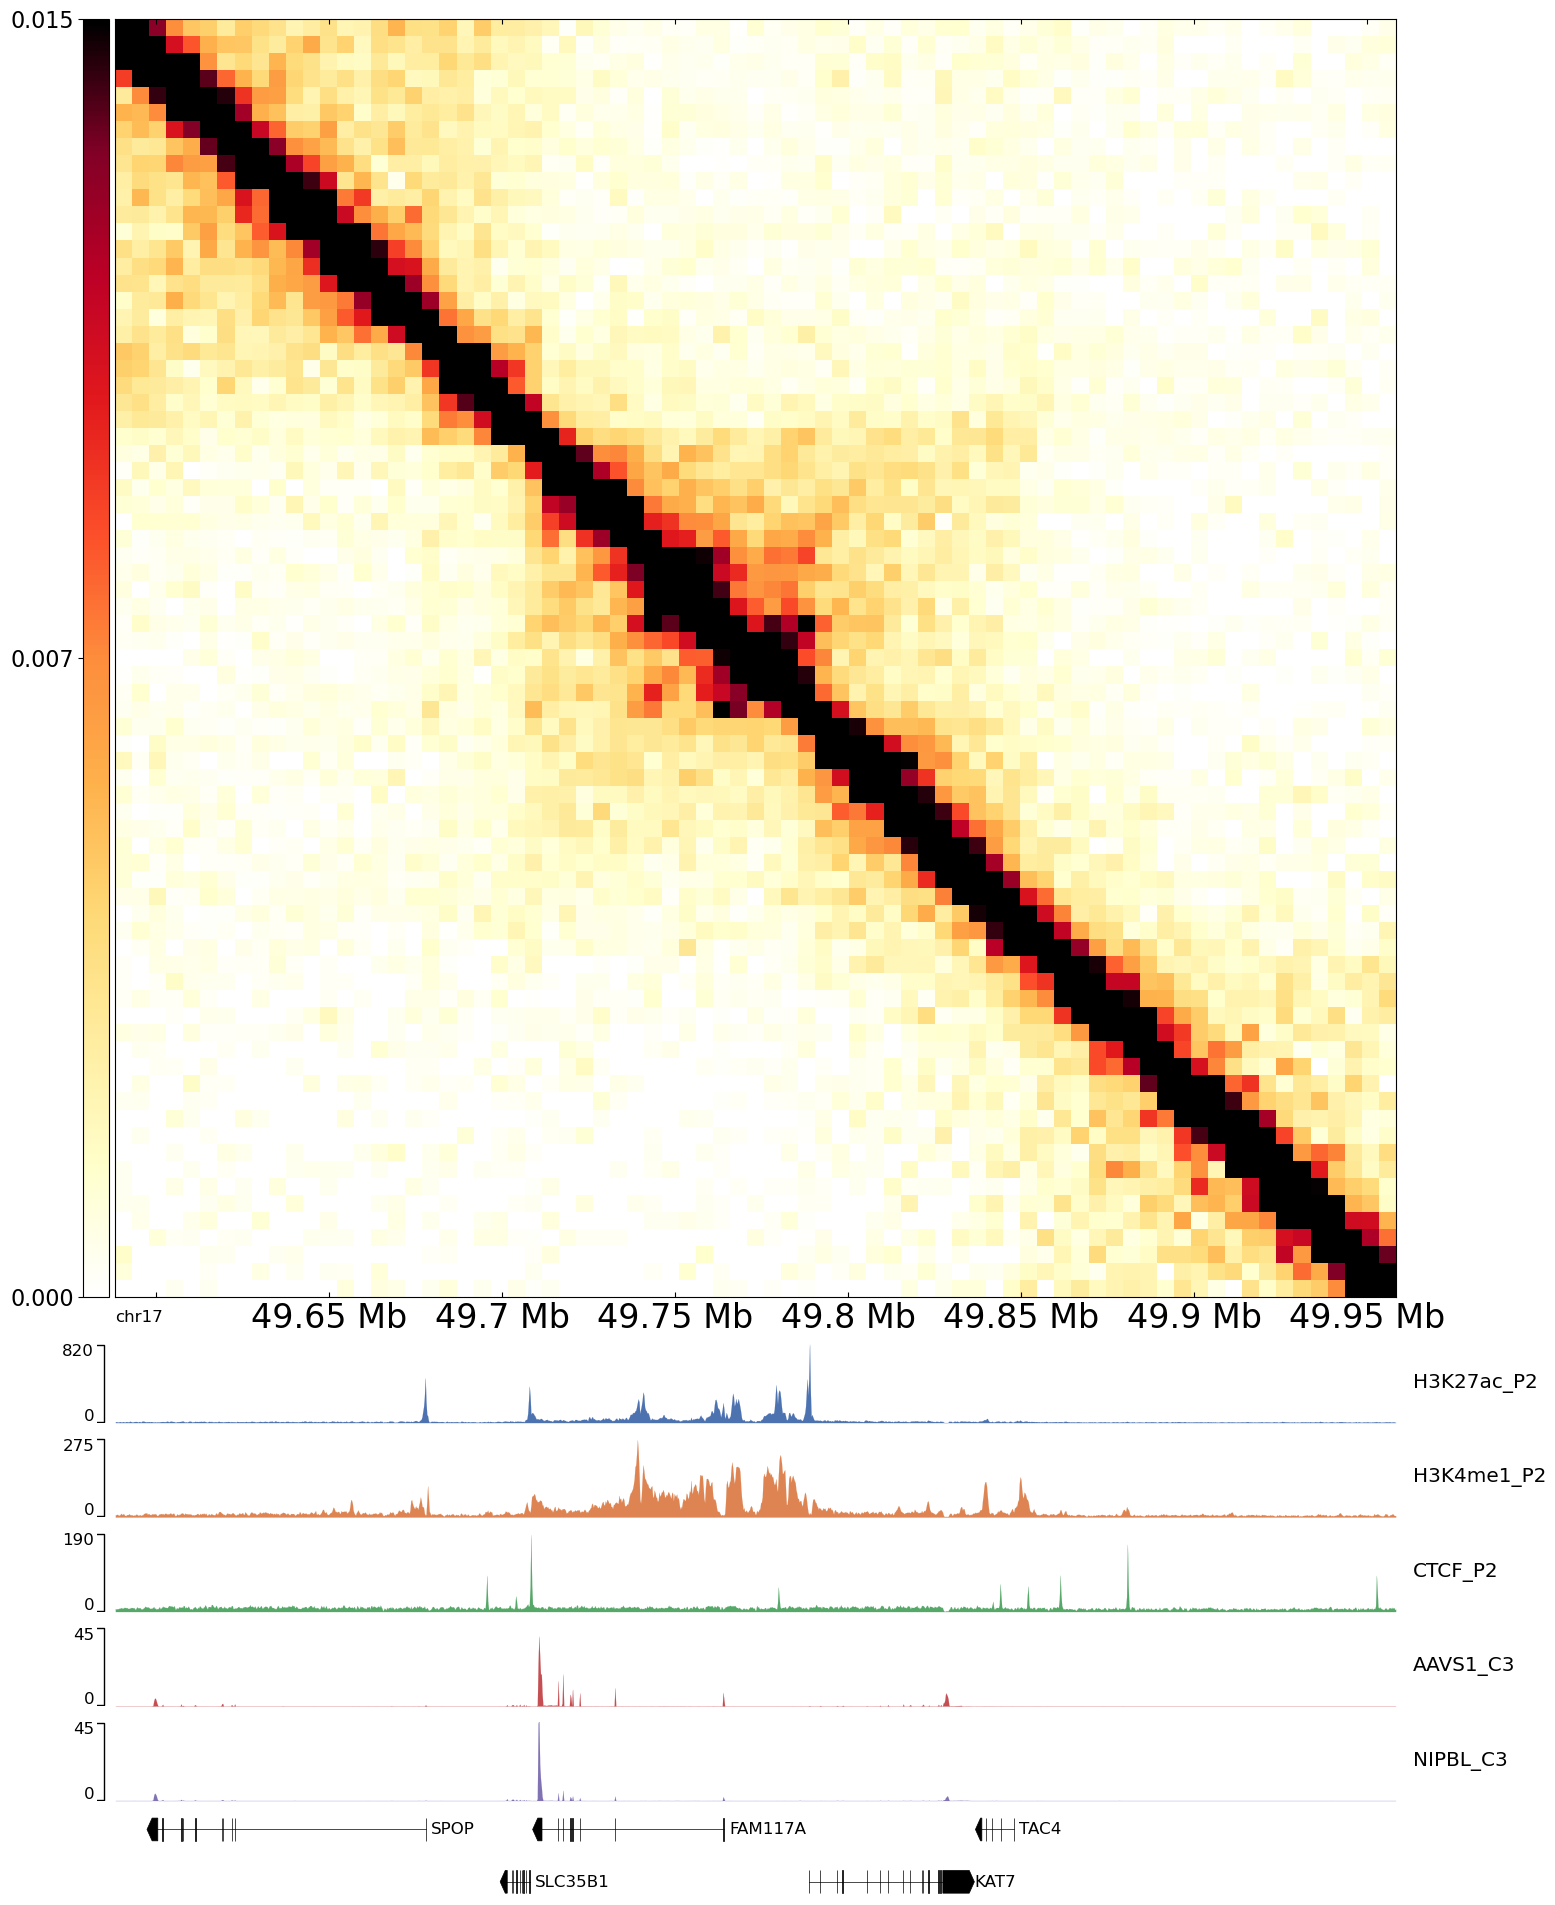

In [31]:
incl= ['H3K27ac_P2', "H3K4me1_P2",'CTCF_P2', 'AAVS1_C3', 'NIPBL_C3']
resolution=5000
# stom locus is good
regname='reg5'
region_str = regions['reg5']

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.015,
                          "min_value":0.000}

chip_list = get_chip_list(include=incl, phase=3, phase2=2)


frame = make_region_plot_mod(region_str, resolution, uc_filenames[1],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[7], cmap_chip="deep", autoscale=False, plot_genes=True, 
                        plot_bed=False, custom_valranges = [820, 275, 190, 45, 45])
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "reg5_c3.svg"))
fig

chr17:49588253-49958253 5000 /mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C2_G1_all.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33040.22it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


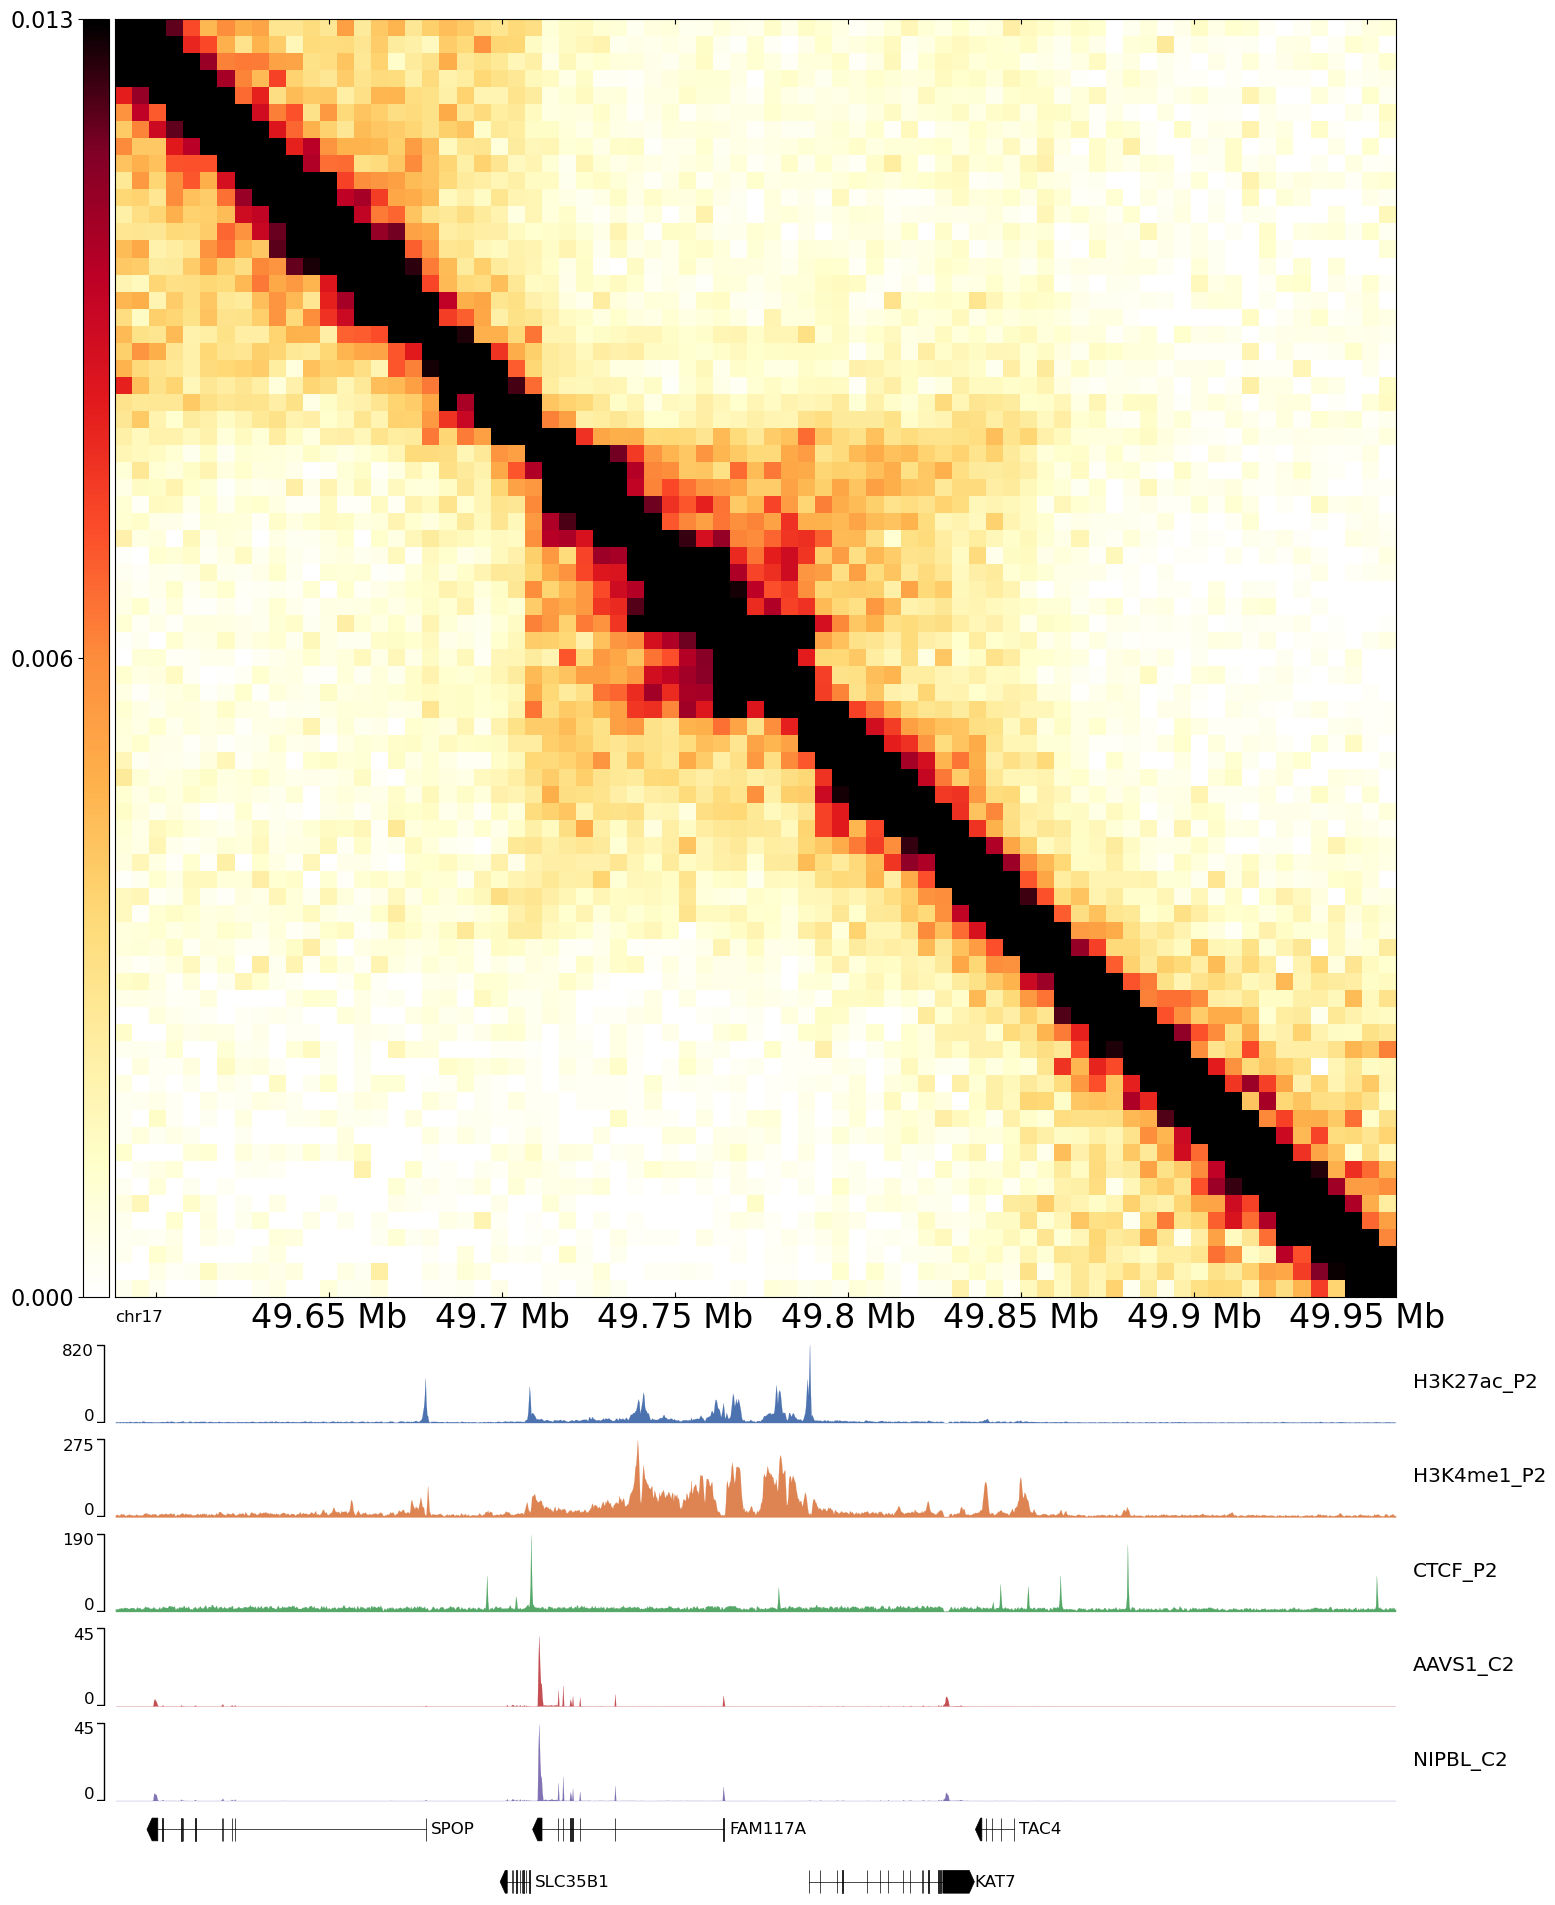

In [32]:
incl= ['H3K27ac_P2', "H3K4me1_P2",'CTCF_P2', 'AAVS1_C2', 'NIPBL_C2']
resolution=5000
# stom locus is good
regname='reg5'
region_str = regions['reg5']

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.0125,
                          "min_value":0.000}

chip_list = get_chip_list(include=incl, phase=3, phase2=2)


frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[6], cmap_chip="deep", autoscale=False, plot_genes=True, 
                        plot_bed=False, custom_valranges = [820, 275, 190, 45, 45])
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "reg5_c2.svg"))
fig

chr16:70214962-70614962 5000 /mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C3_G1_all.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33344.35it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


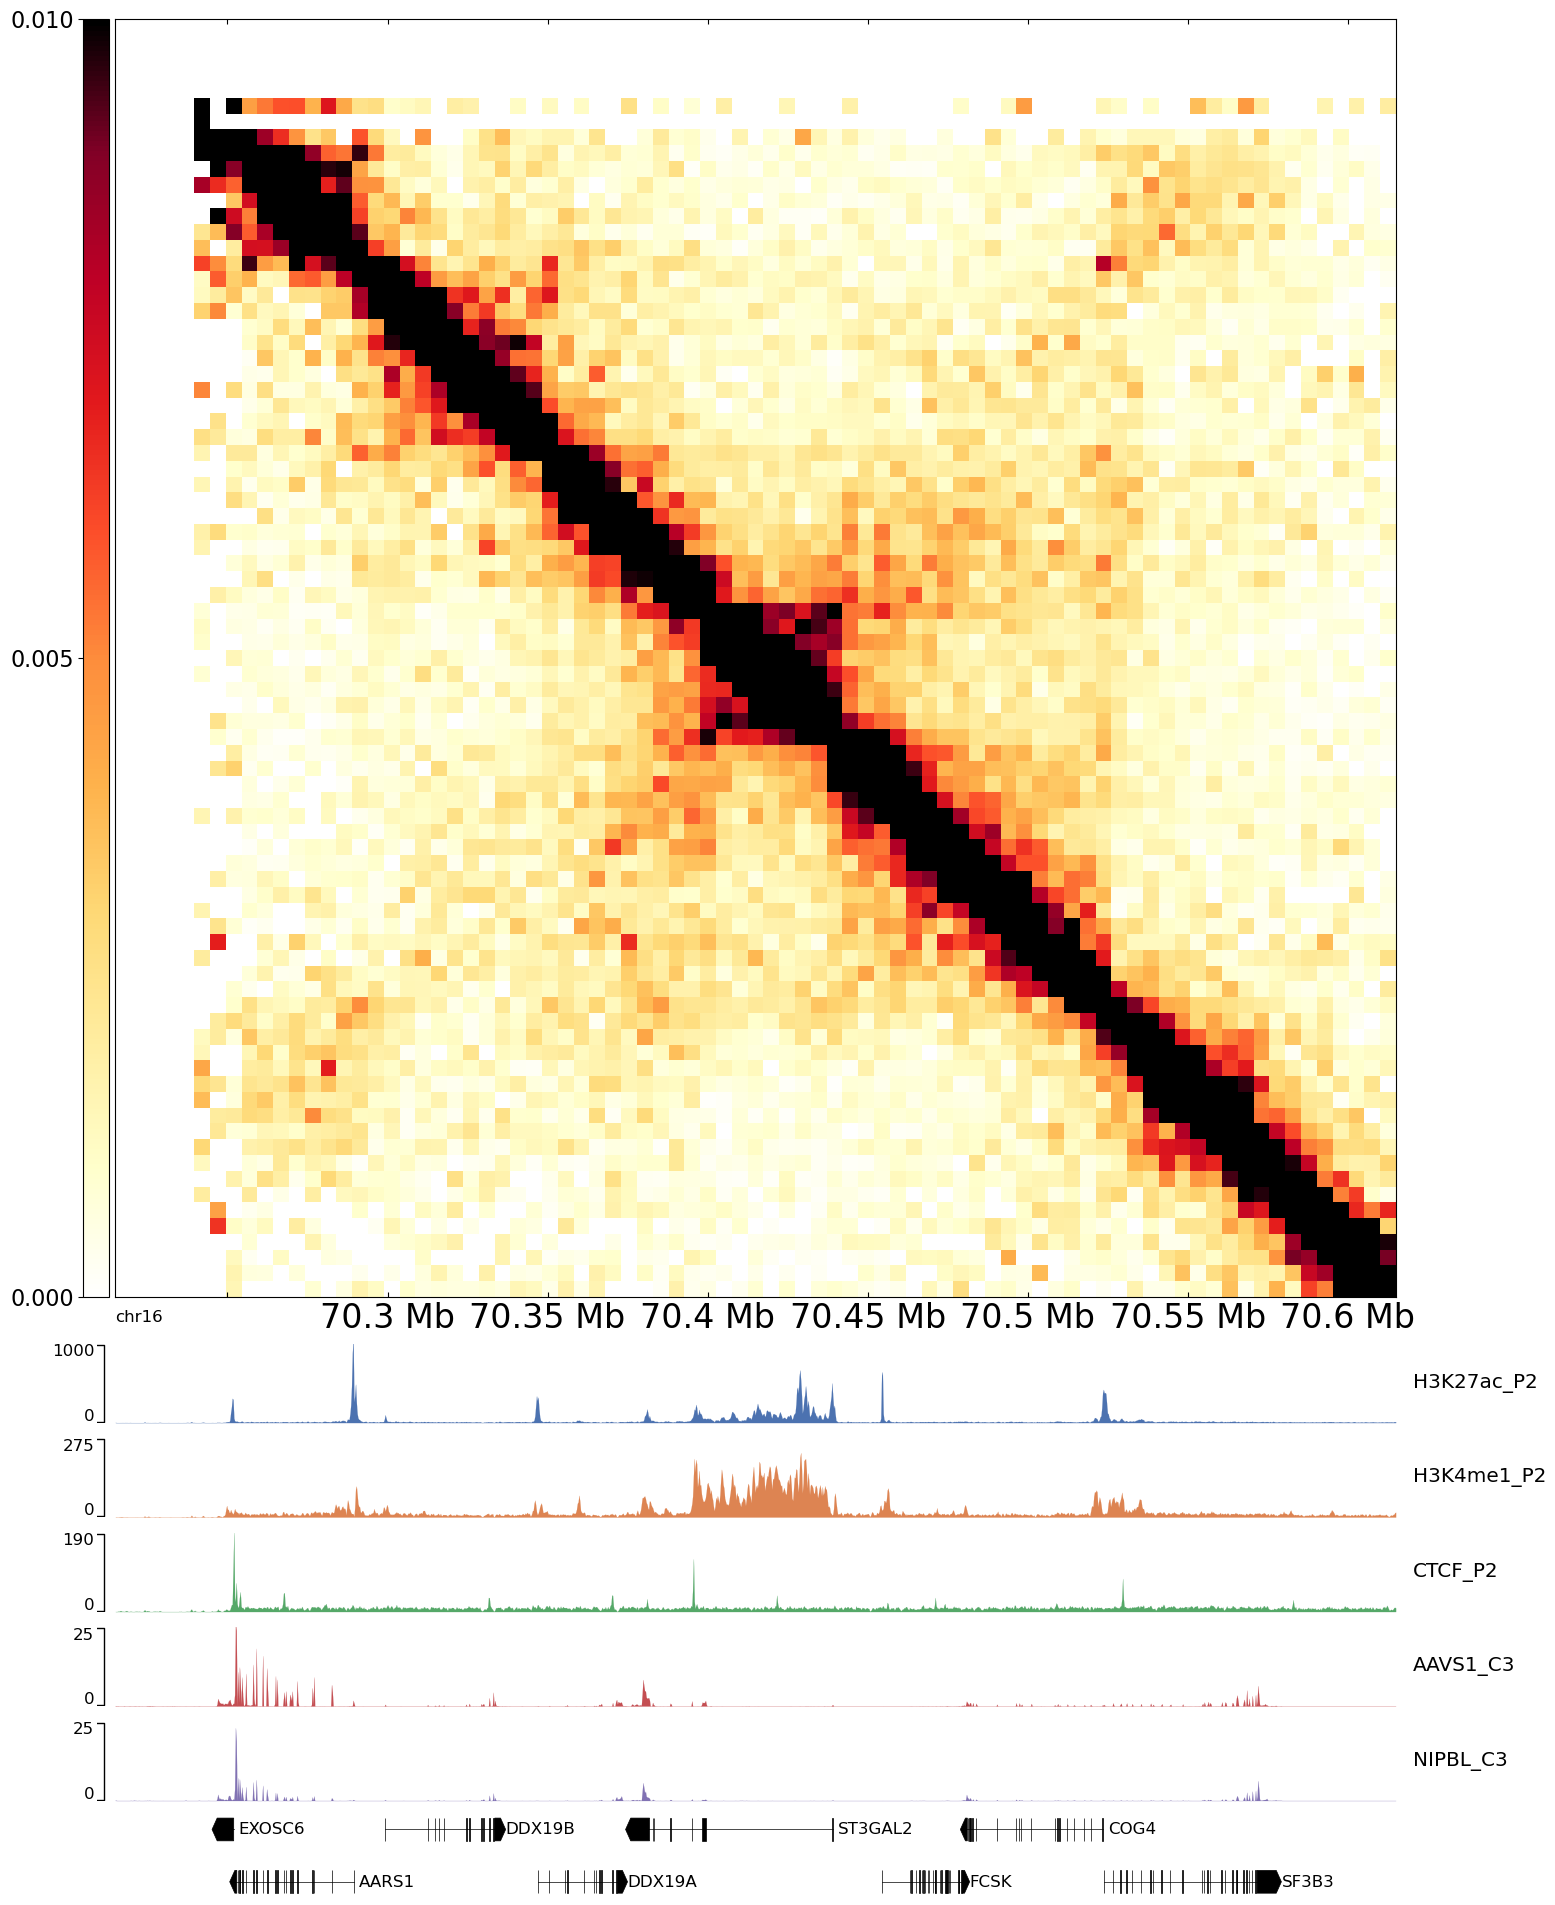

In [25]:
incl= ['H3K27ac_P2', "H3K4me1_P2",'CTCF_P2', 'AAVS1_C3', 'NIPBL_C3']
resolution=5000

region_str = 'chr16:70214962-70614962'

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.01,
                          "min_value":0.000}

chip_list = get_chip_list(include=incl, phase=3, phase2=2)

frame = make_region_plot_mod(region_str, resolution, uc_filenames[1],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[7], cmap_chip="deep", autoscale=False, plot_genes=True, 
                        plot_bed=False, custom_valranges=[1000, 275, 190, 25, 25])
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "st3gal_nipbl_c3.svg"))

fig

chr16:70214962-70614962 5000 /mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C2_G1_all.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33084.73it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


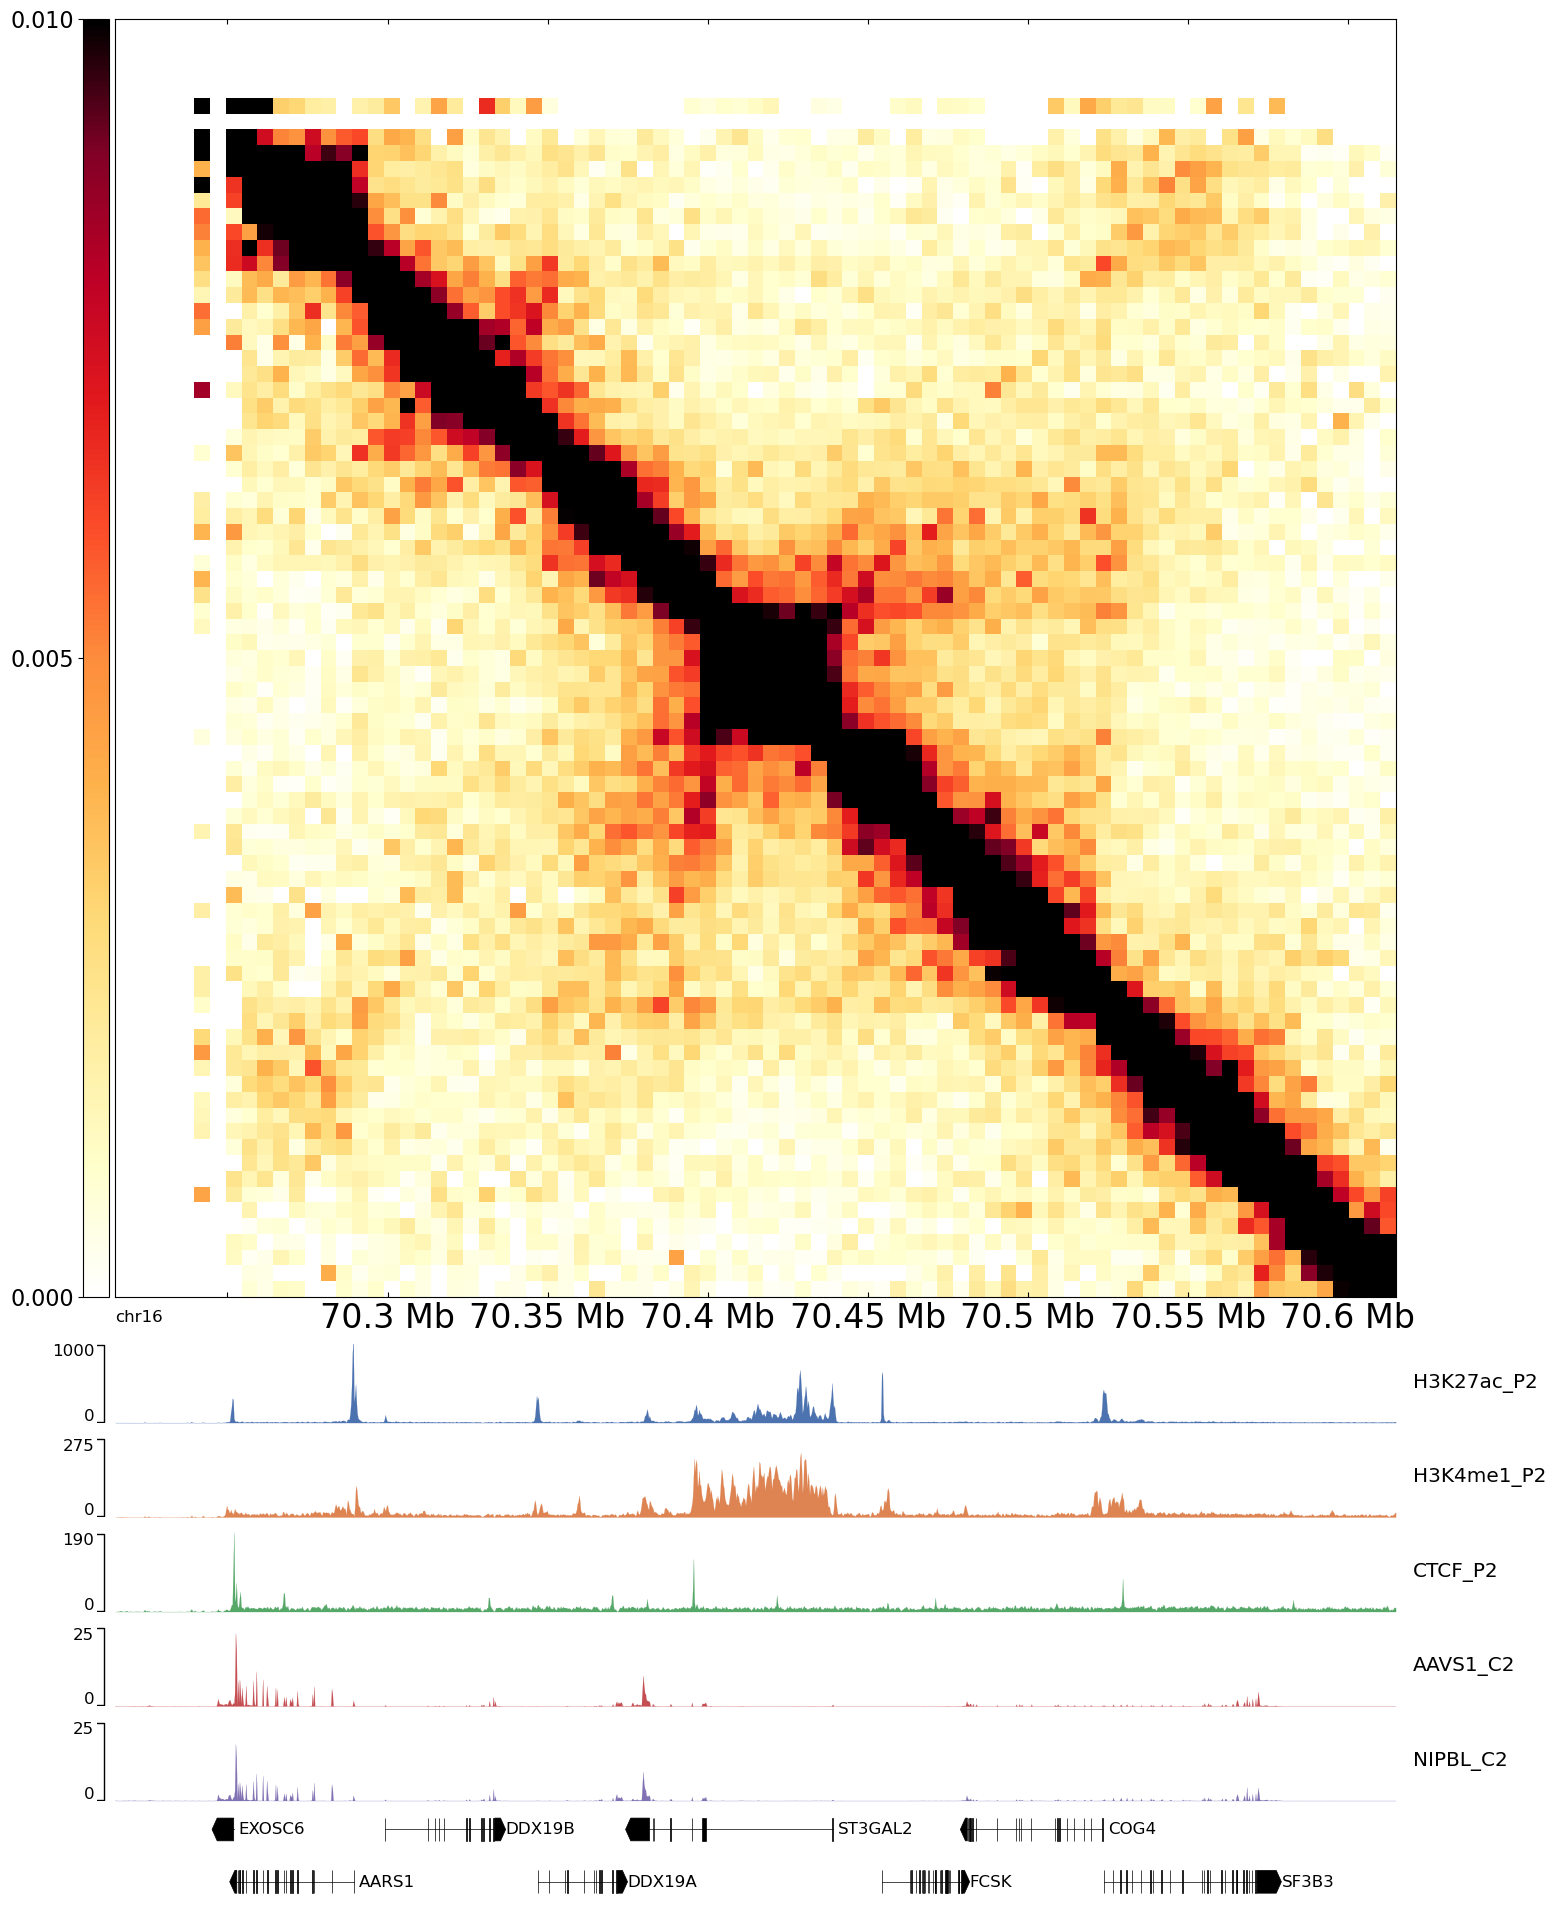

In [18]:
incl= ['H3K27ac_P2', "H3K4me1_P2",'CTCF_P2', 'AAVS1_C2', 'NIPBL_C2']
resolution=5000

region_str = 'chr16:70214962-70614962'

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.01,
                          "min_value":0.000}

chip_list = get_chip_list(include=incl, phase=3, phase2=2)

frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[6], cmap_chip="deep", autoscale=False, plot_genes=True, 
                        plot_bed=False, custom_valranges=[1000, 275, 190, 25, 25])
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "st3gal_nipbl_c2.svg"))

fig

chr17:44081815-44481815 5000 /mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C3_G1_all.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33523.08it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 7.9799999999999995,-0.08


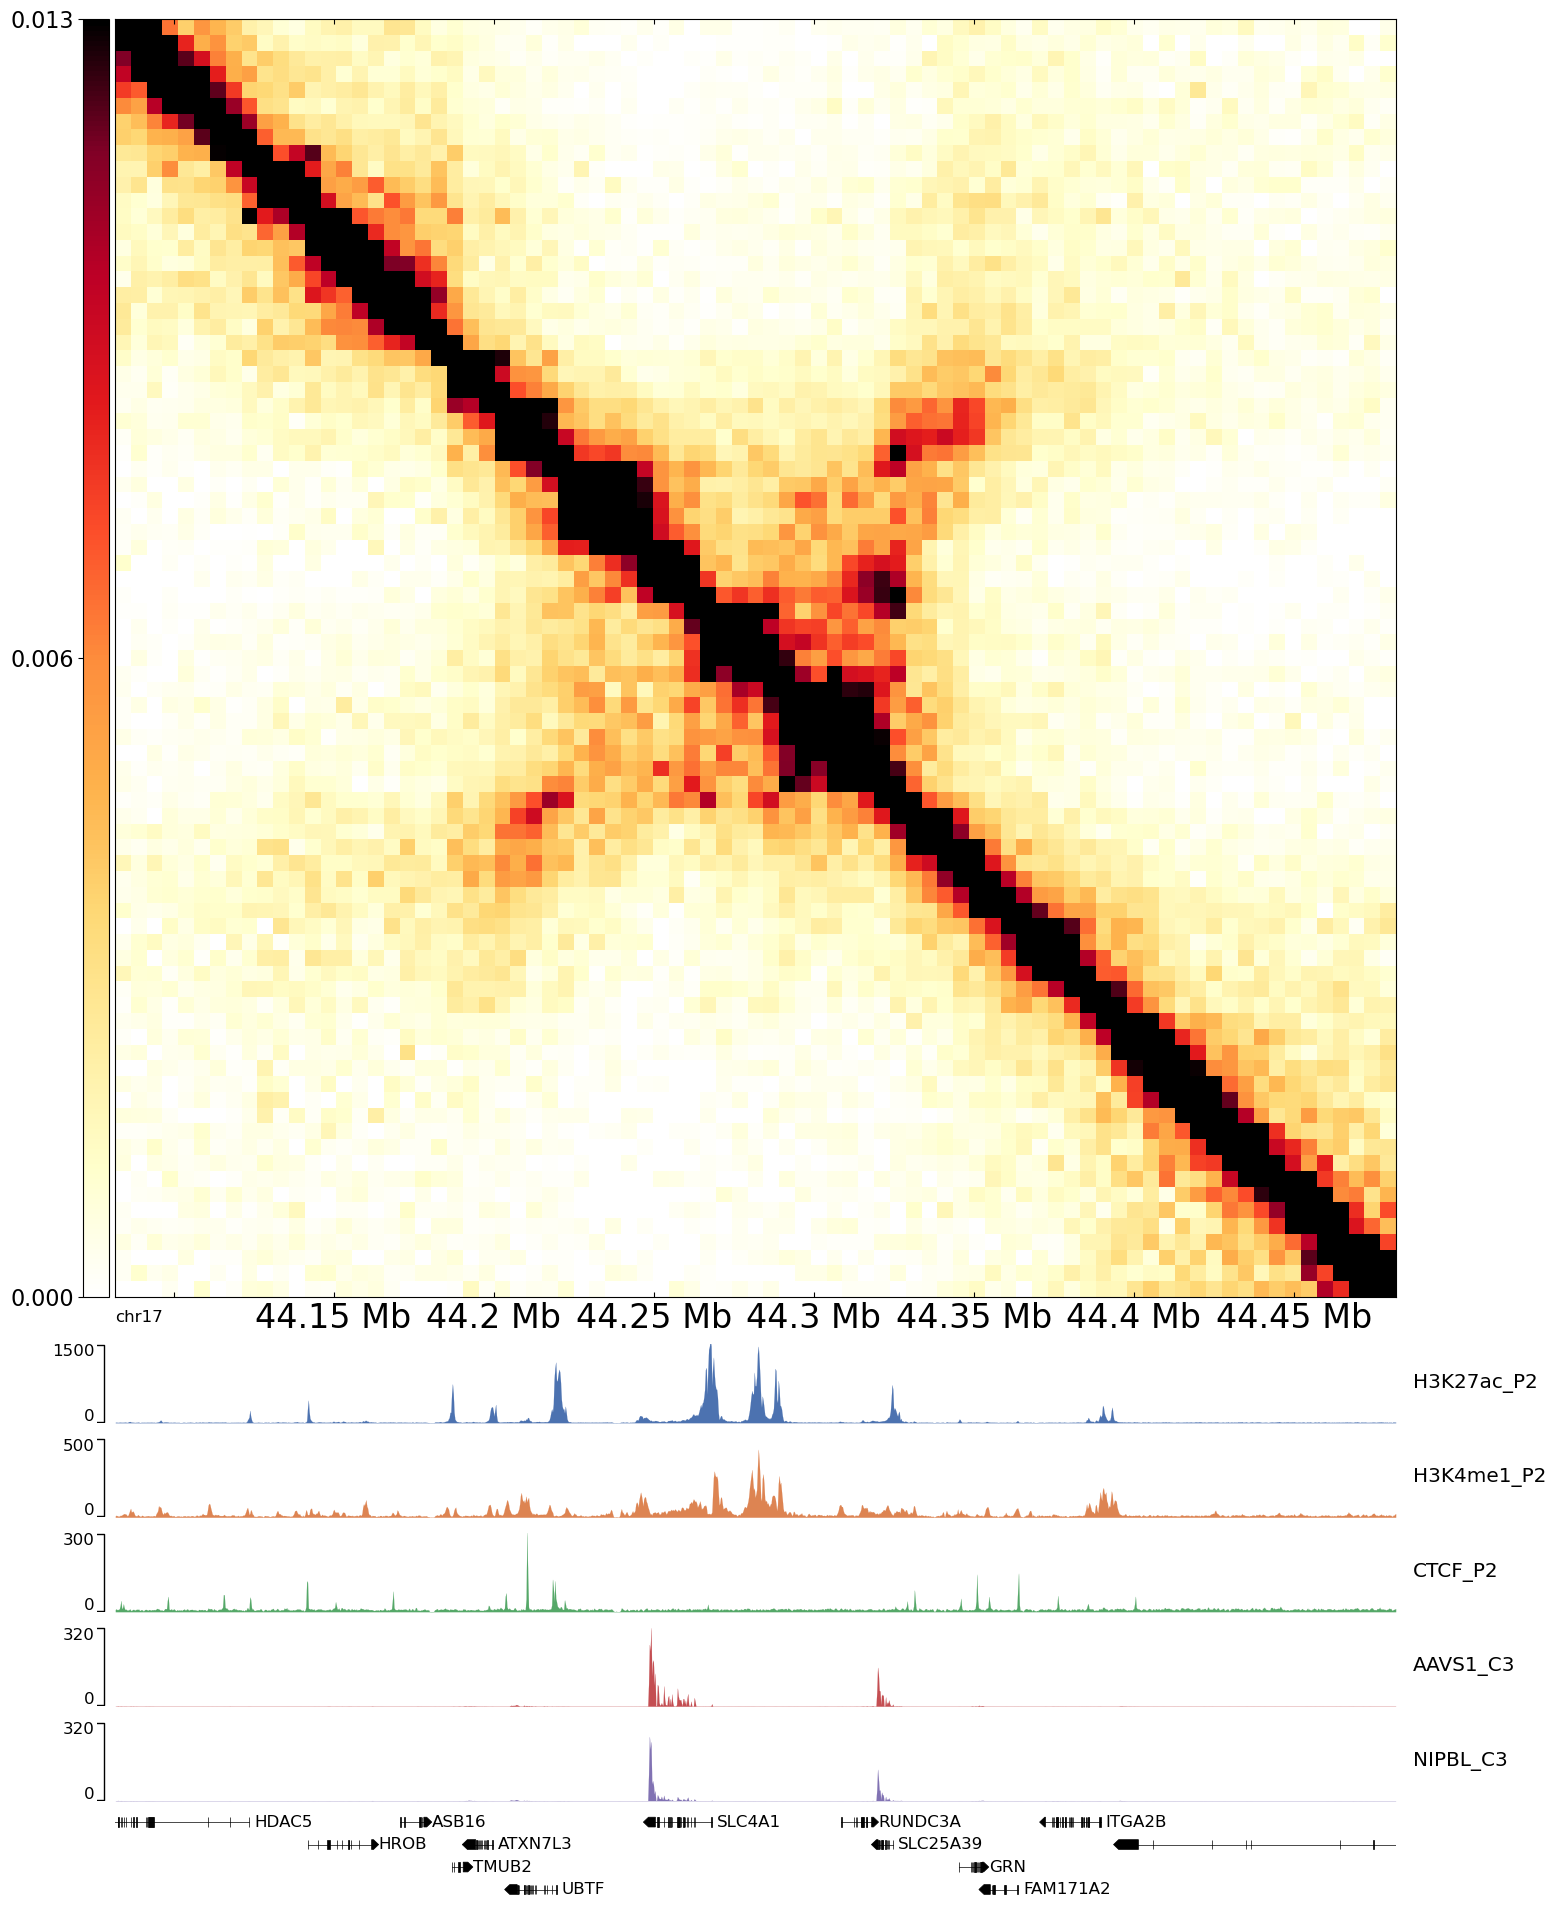

In [26]:
incl= ['H3K27ac_P2', "H3K4me1_P2",'CTCF_P2', 'AAVS1_C3', 'NIPBL_C3']
resolution=5000
region_str = 'chr17:44081815-44481815'

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.015,
                          "min_value":0.000}

chip_list = get_chip_list(include=incl, phase=3, phase2=2)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[1],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[7], cmap_chip="deep", autoscale=False, plot_genes=True, 
                        plot_bed=False, custom_valranges=[1500, 500, 300, 320, 320])
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "slc4a1_c3.svg"))
fig

chr17:44081815-44481815 5000 /mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C2_G1_all.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33015.23it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 7.9799999999999995,-0.08


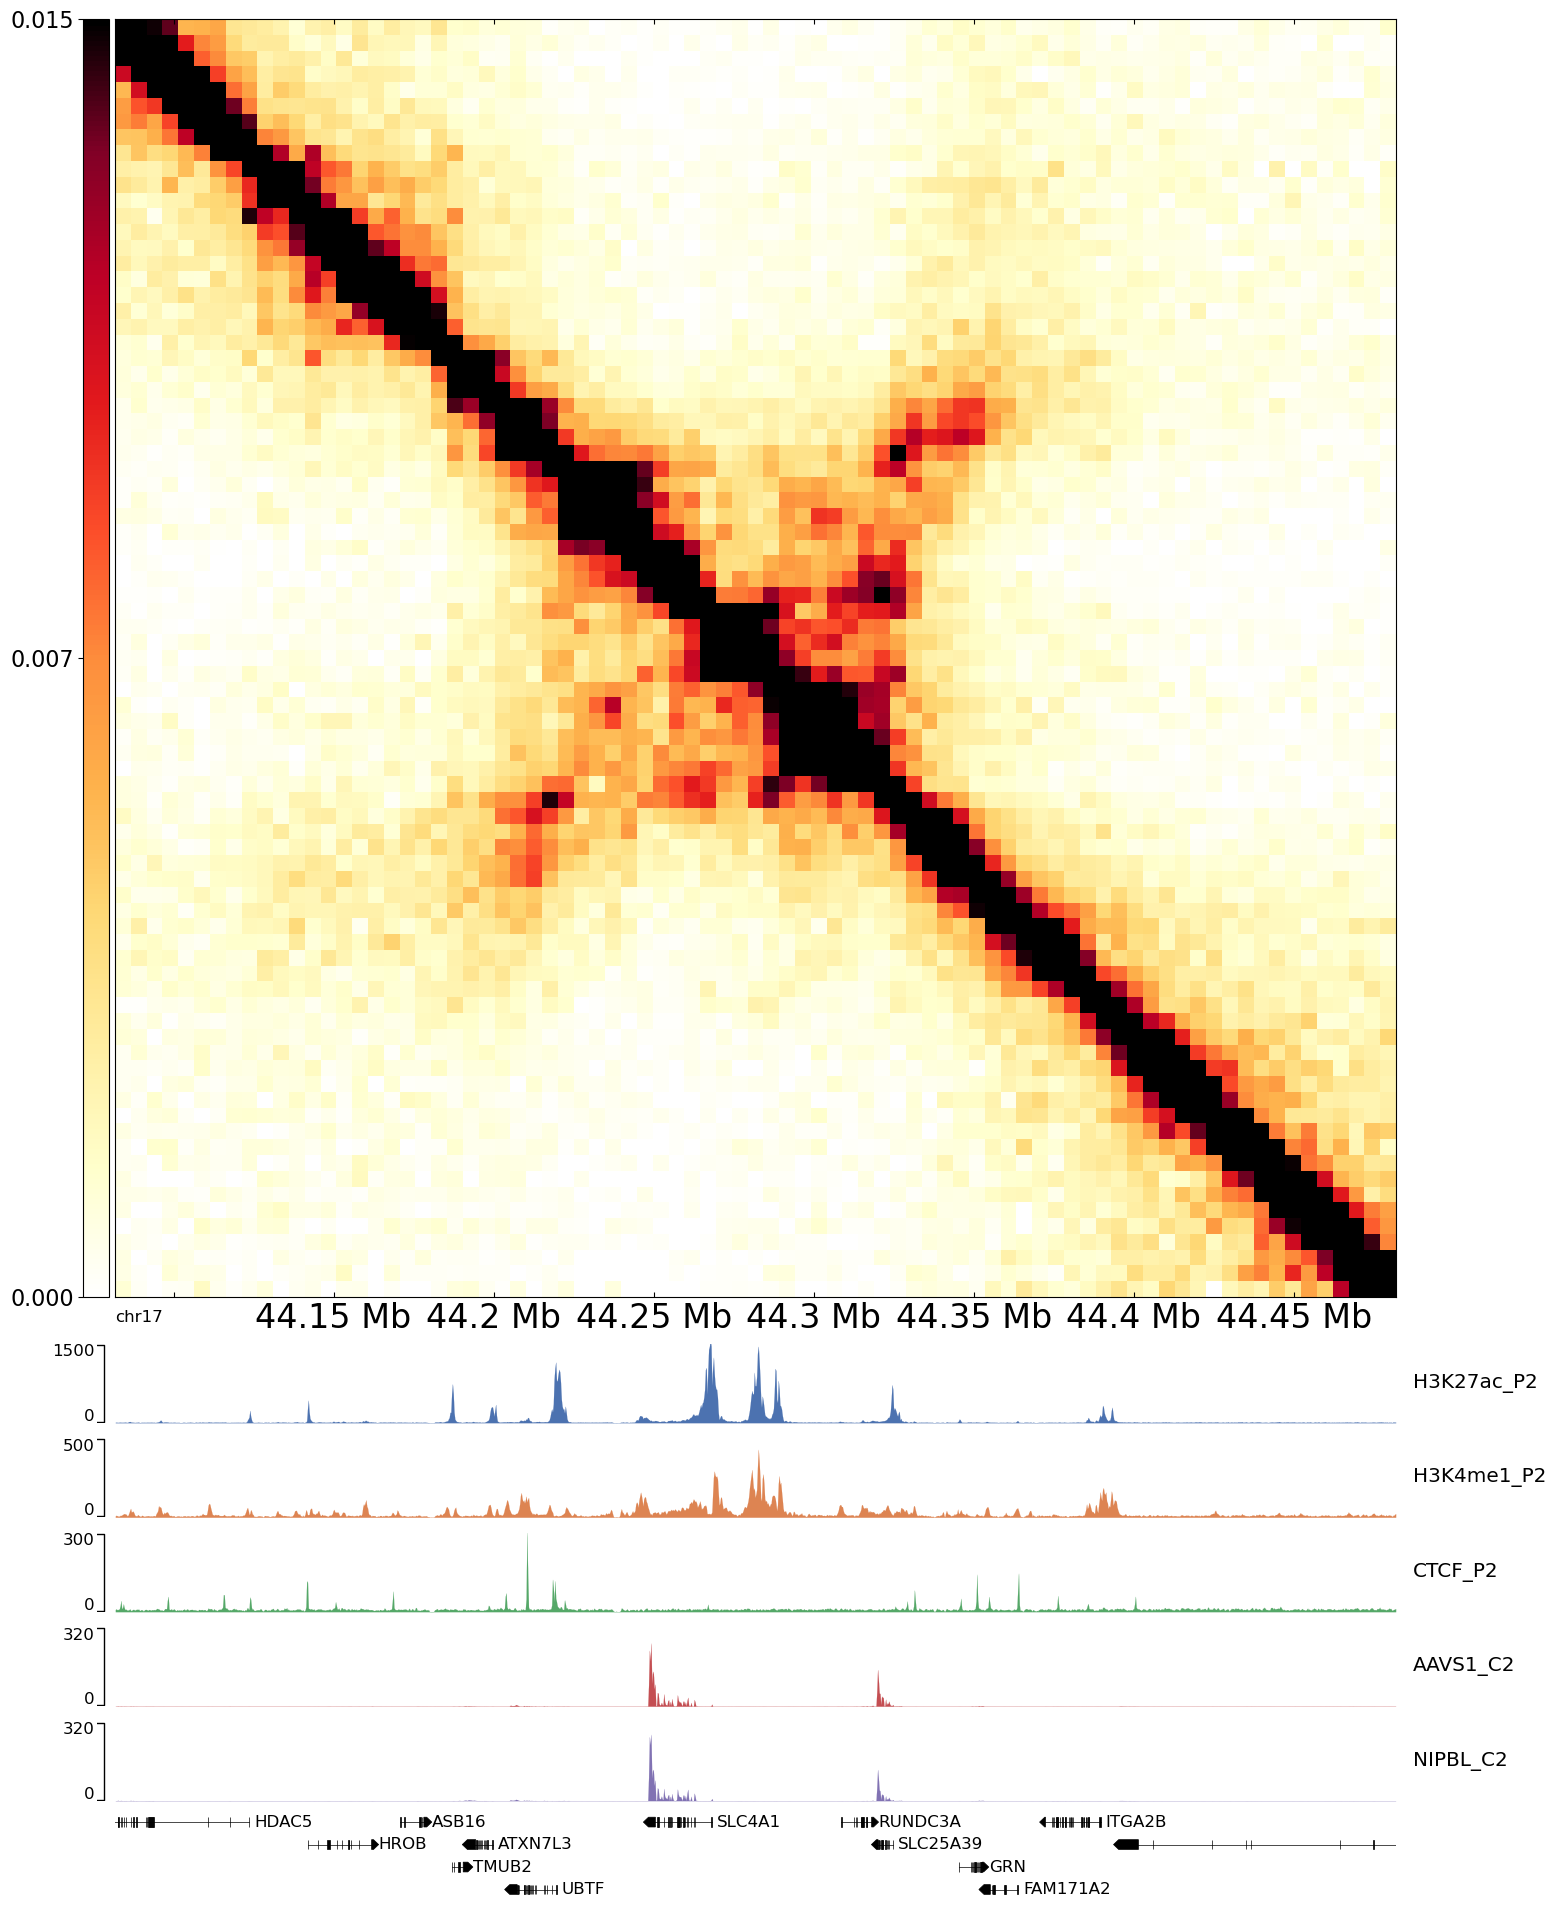

In [27]:
incl= ['H3K27ac_P2', "H3K4me1_P2",'CTCF_P2', 'AAVS1_C2', 'NIPBL_C2']
resolution=5000
region_str = 'chr17:44081815-44481815'

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.015,
                          "min_value":0.000}

chip_list = get_chip_list(include=incl, phase=3, phase2=2)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[6], cmap_chip="deep", autoscale=False, plot_genes=True, 
                        plot_bed=False, custom_valranges=[1500, 500, 300, 320, 320])
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "slc4a1_c2.svg"))
fig

chr12:54105812-54505812 5000 /mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C3_G1_all.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 32446.04it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 5.68,-0.08


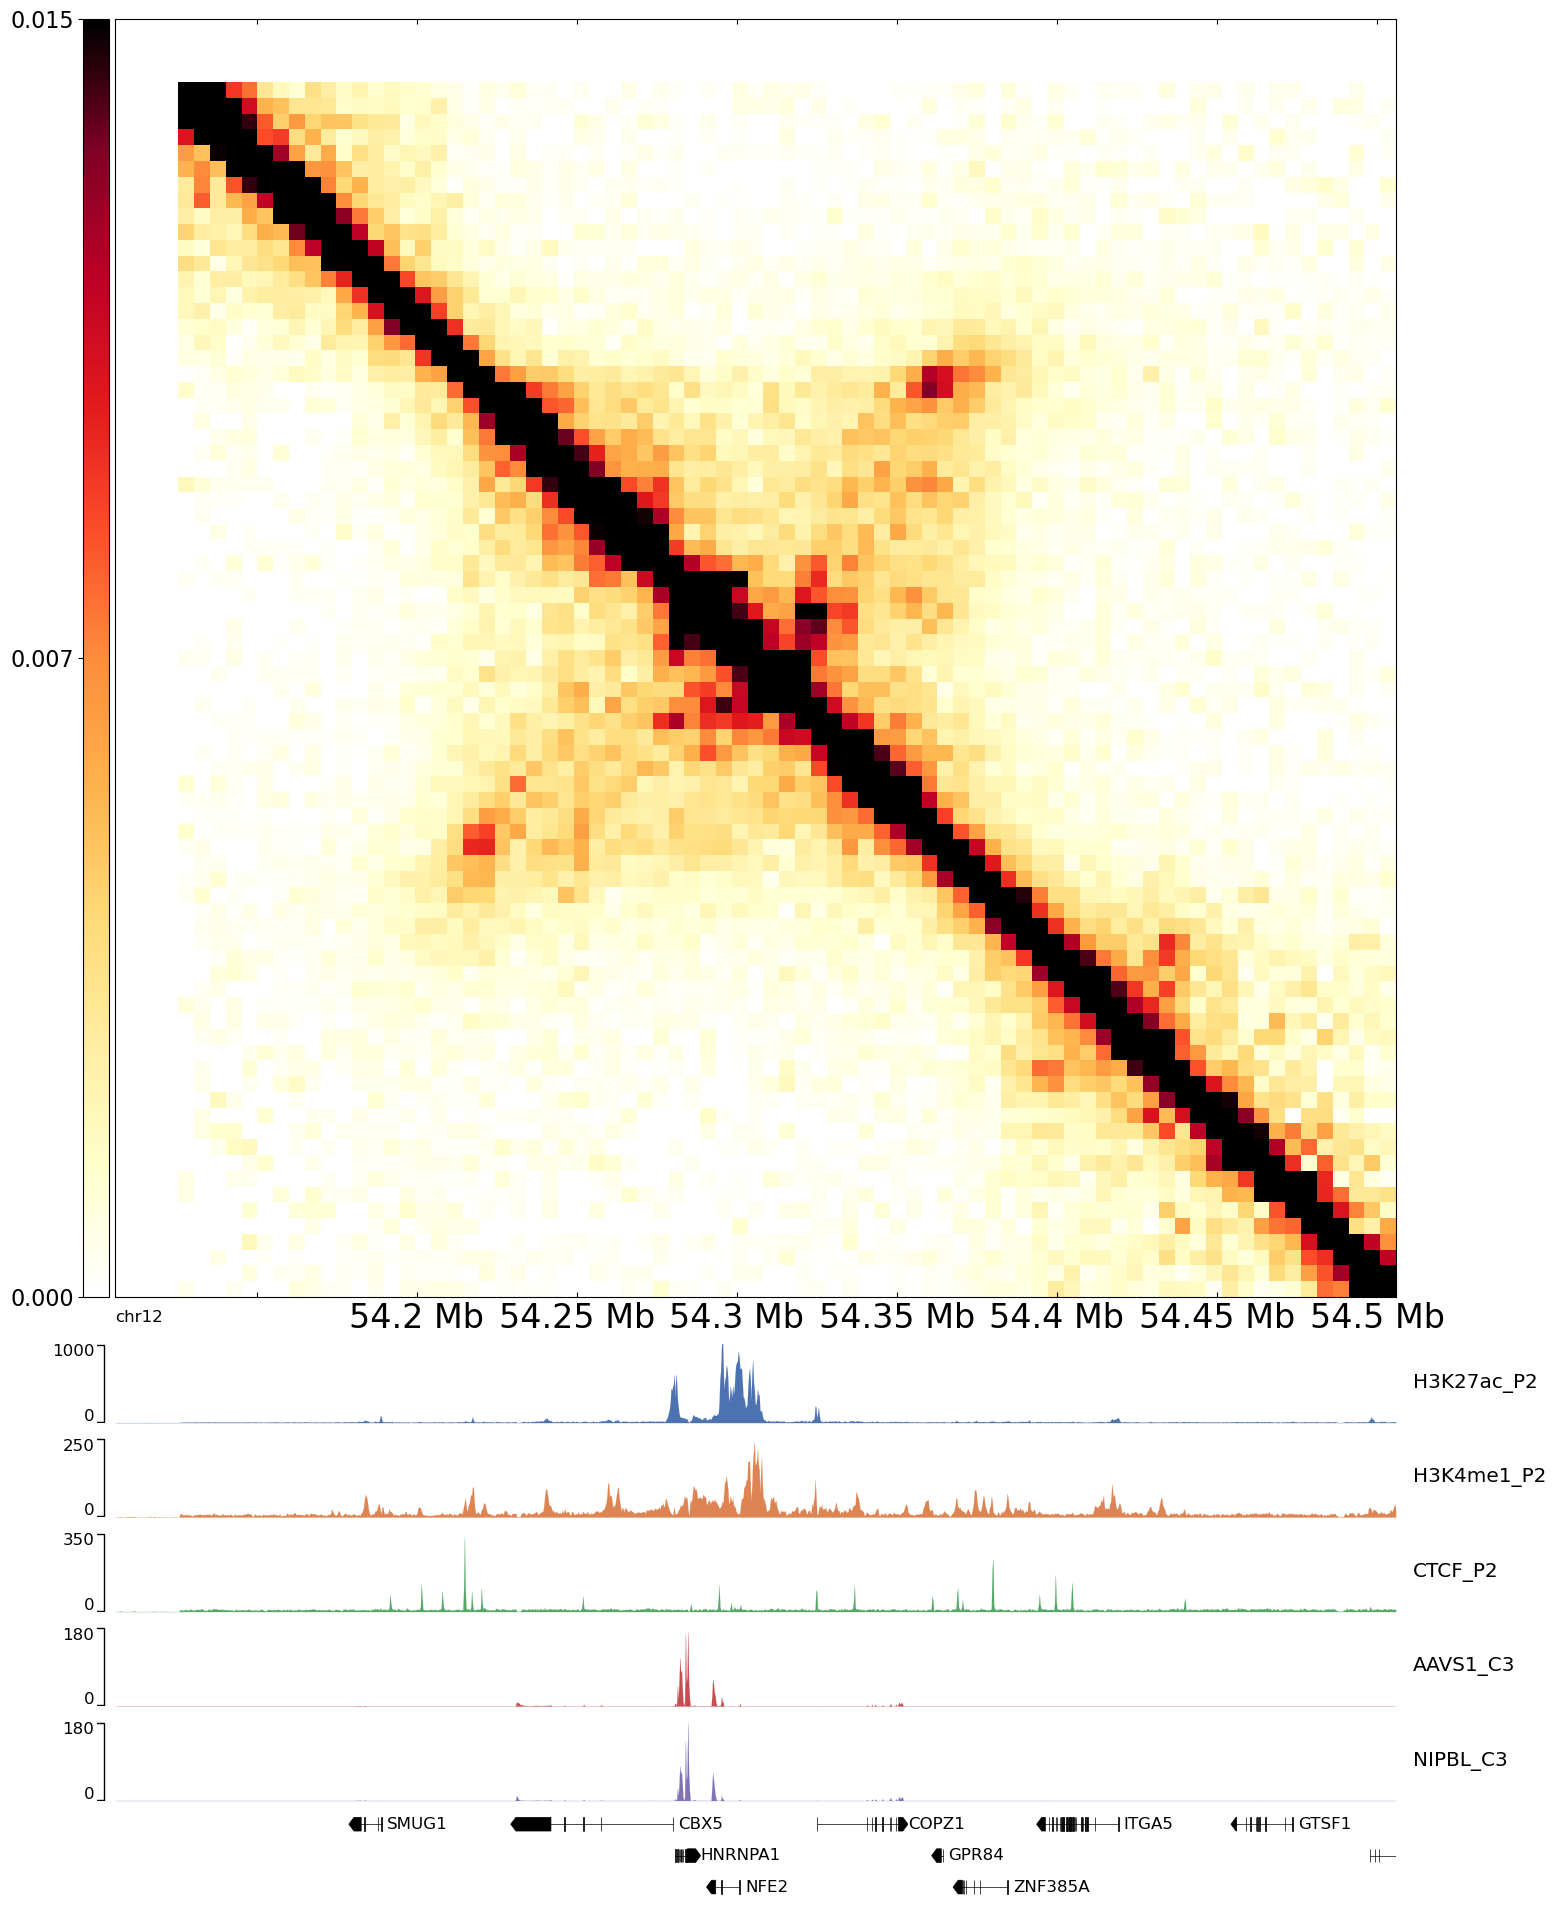

In [66]:
incl= ['H3K27ac_P2', "H3K4me1_P2",'CTCF_P2', 'AAVS1_C3', 'NIPBL_C3']
resolution=5000

regname='chr12:54105812-54505812'
region_str = 'chr12:54105812-54505812'
MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.015,
                          "min_value":0.000}

chip_list = get_chip_list(include=incl, phase=3, phase2=2)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[1],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[7], cmap_chip="deep", autoscale=False, plot_genes=True, 
                        plot_bed=False, custom_valranges=[1000, 250, 350, 180, 180])
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "nfe2_nipbl_c3.svg"))
fig



chr12:54105812-54505812 5000 /mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C2_G1_all.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33034.27it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 5.68,-0.08


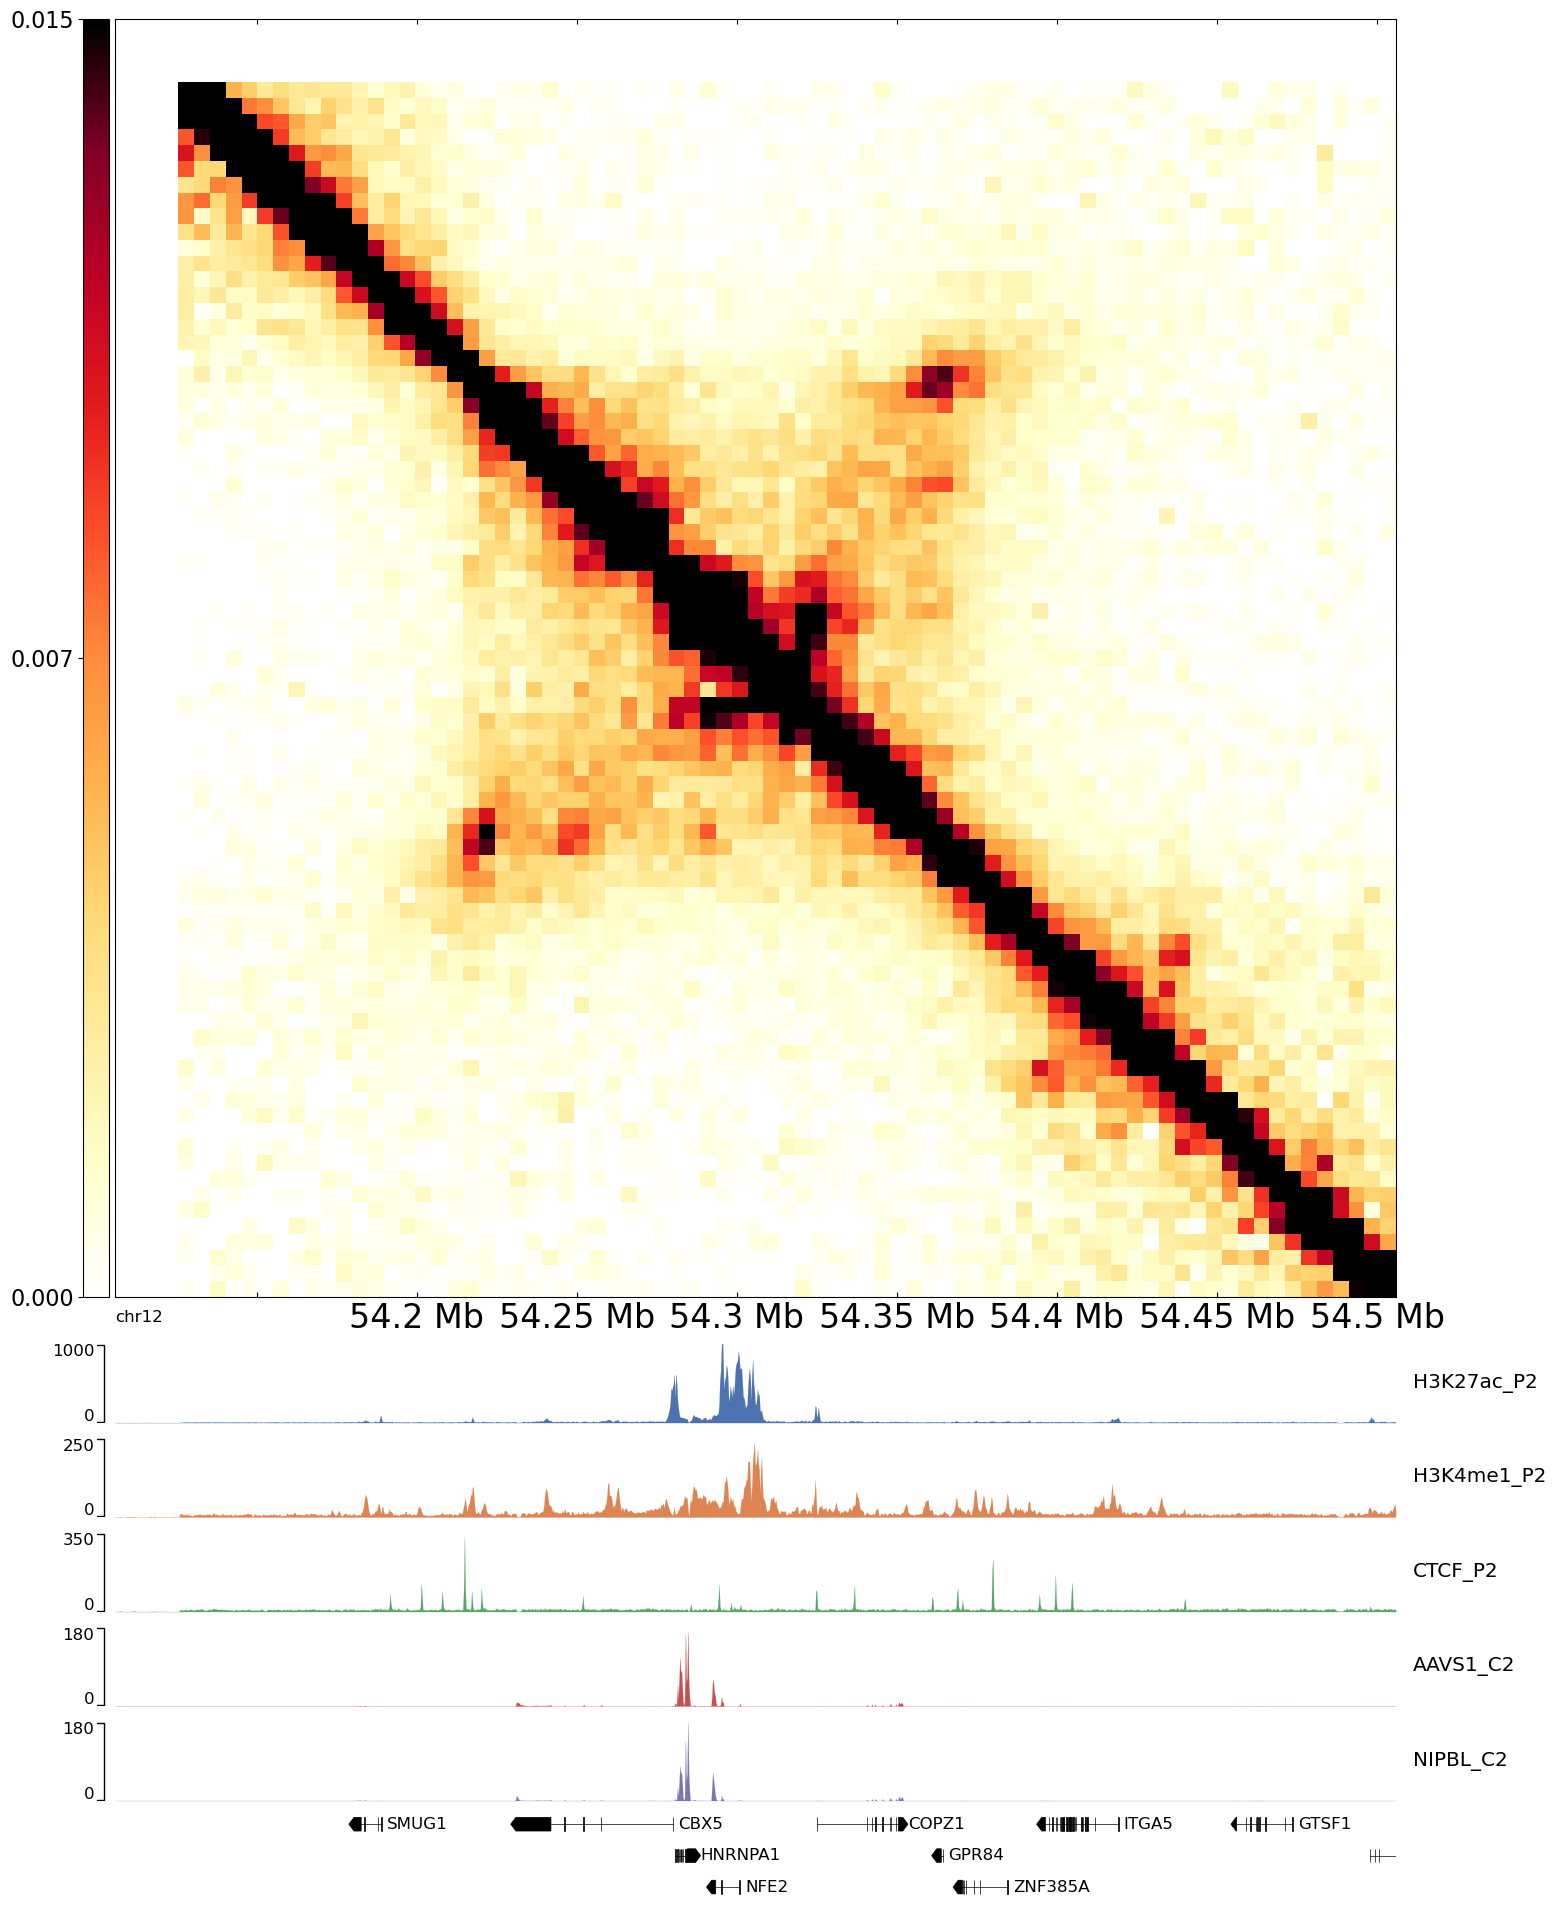

In [67]:
incl= ['H3K27ac_P2', "H3K4me1_P2",'CTCF_P2', 'AAVS1_C2', 'NIPBL_C2']


MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.015,
                          "min_value":0.000}
frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[6], cmap_chip="deep", autoscale=False, plot_genes=True, 
                        plot_bed=False, custom_valranges=[1000, 250, 350, 180, 180])
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "nfe2_nipbl_c2.svg"))

fig

100%|██████████████████████████████████| 22438/22438 [00:01<00:00, 13091.87it/s]


bar is on
32.45700000000001
37.2


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 14.879999999999999,-0.08


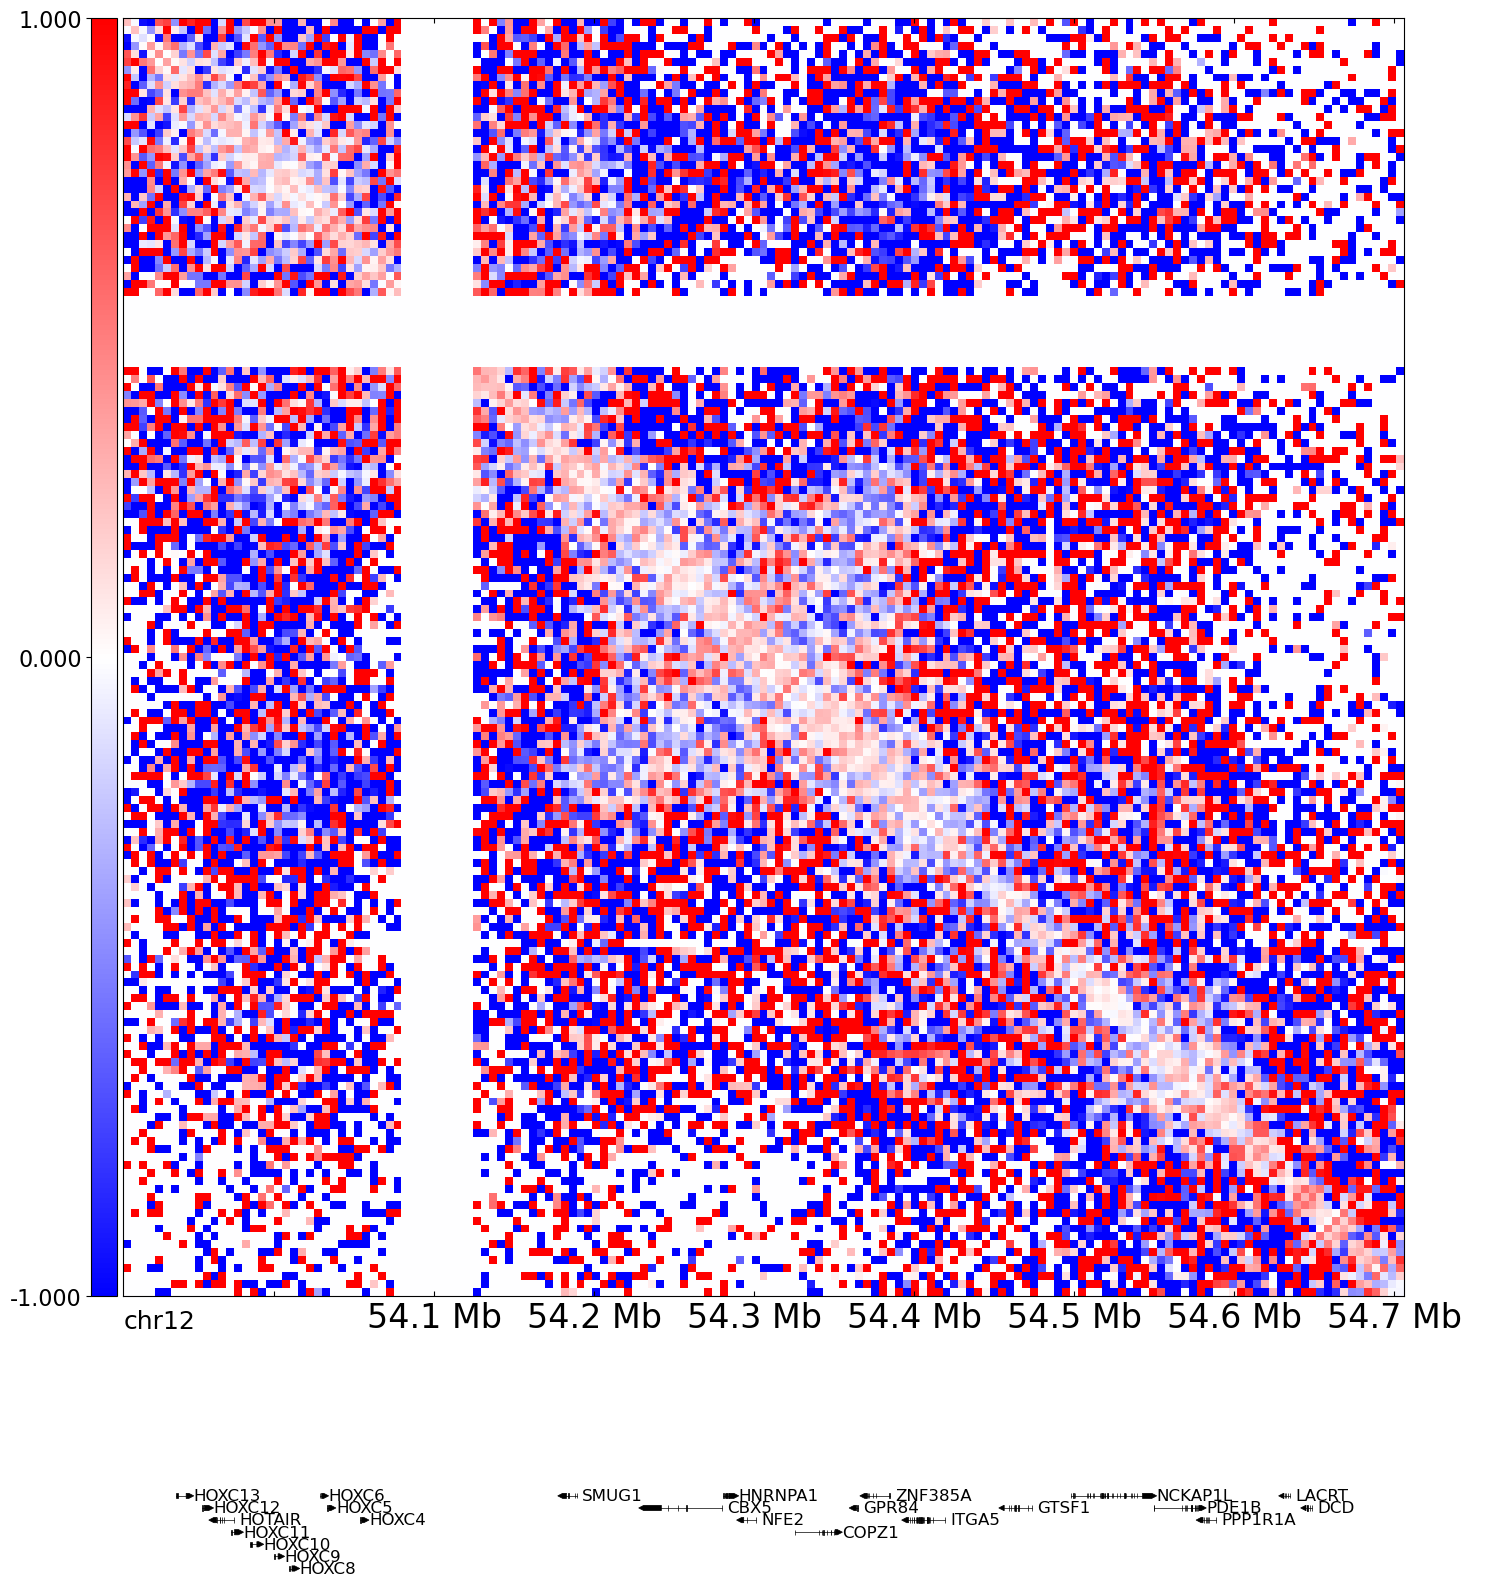

In [19]:
resolution = 5000
#region_str = get_locus_from_coord(nfe2_peaks.iloc[36, :], flank=400_000)
region_str = "chr12:53905812-54705812"
HICDIFF_PLOTTING_PARAMS = {"fontsize":18}


microc_file1 = uc_filenames[7]
microc_file2 = uc_filenames[1]
microc_title = f"{region_str} at {resolution}"
frame = HiCDiff2(microc_file1, microc_file2, diff_method='log2fc', cmap="bwr", 
                        style="matrix", max_value=1, min_value=-1, transform="linear", 
                         resolution=resolution, **HICDIFF_PLOTTING_PARAMS)
frame+=Spacer(5) # ridiculous large spacer, you can add the chips like in the plotting function above instead
annotations = NewBed(*GTF_PARAMS)
frame += annotations
fig = frame.plot(region_str)
fig


chr9:121151319-121551319 5000 /mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C3_G1_all.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33148.65it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


chr9:121151319-121551319 5000 /mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep/AAVS1_C2_G1_all.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 31924.09it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


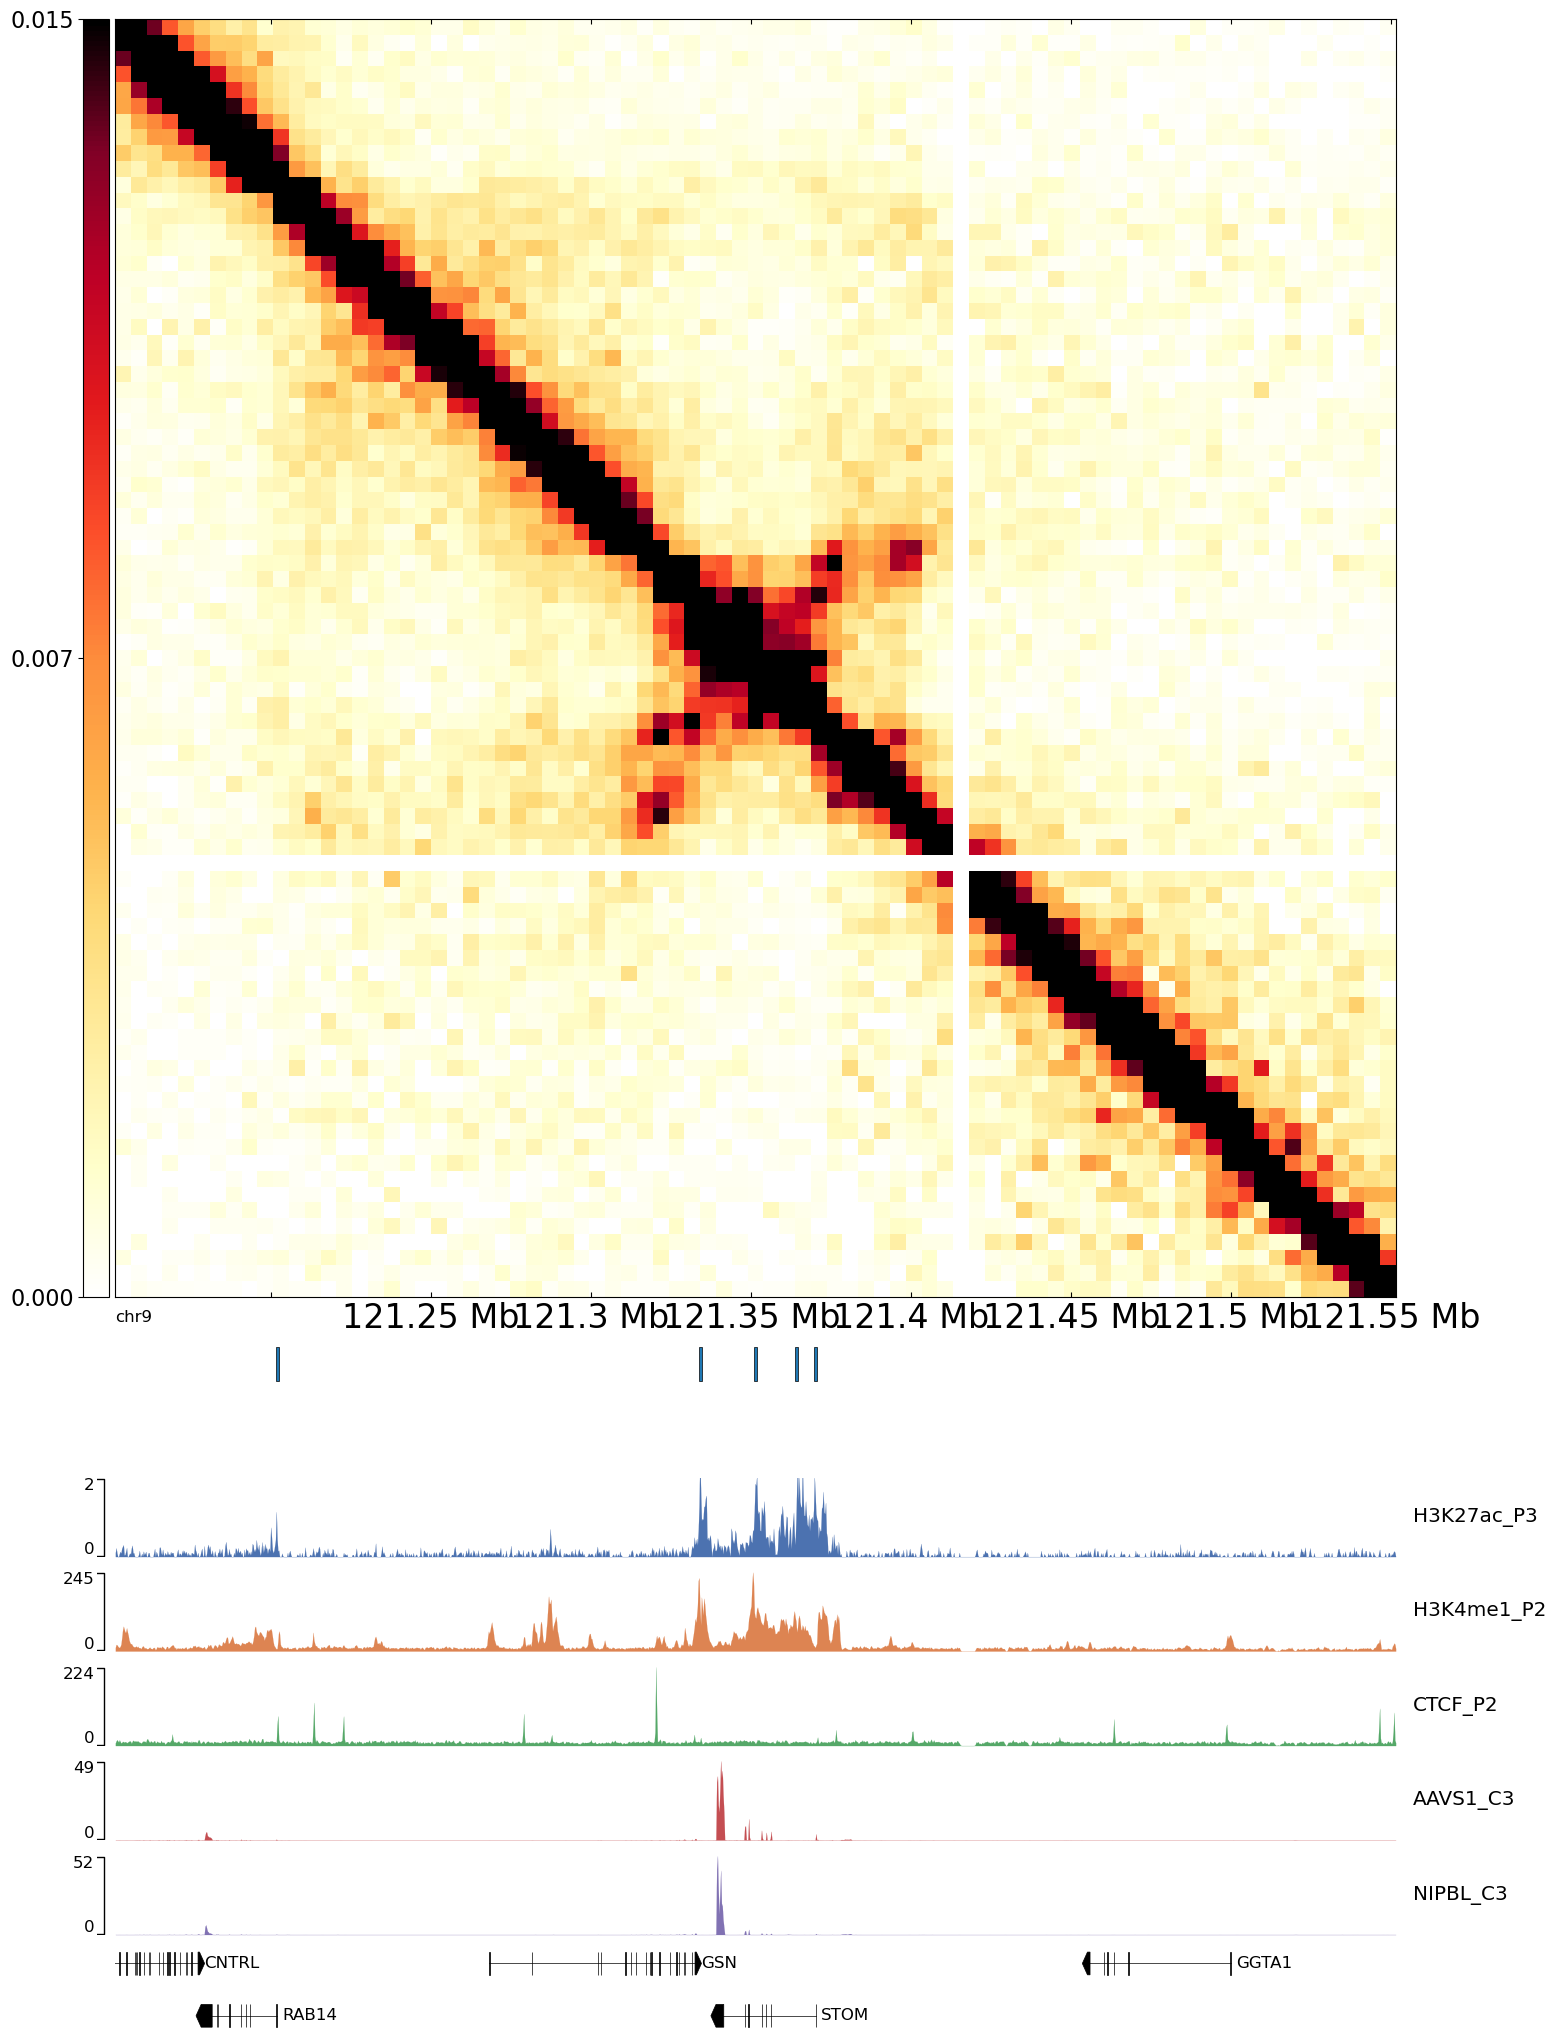

In [16]:

incl= ['H3K27ac_P3', "H3K4me1_P2",'CTCF_P2', 'AAVS1_C3', 'NIPBL_C3']
resolution=5000

region_str = 'chr9:121151319-121551319'

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.015,
                          "min_value":0.000}

chip_list = get_chip_list(include=incl, phase=3, phase2=2)

frame = make_region_plot_mod(region_str, resolution, uc_filenames[1],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[7], cmap_chip="deep", autoscale=True, plot_genes=True, 
                        plot_bed=True)
fig = frame.plot(region_str)
#fig.savefig(os.path.join(savedir, "stom_nipbl_c3.svg"))

frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[6], cmap_chip="deep", autoscale=True, plot_genes=True, 
                        plot_bed=True)
fig = frame.plot(region_str)
#fig.savefig(os.path.join(savedir, "stom_nipbl_c2.svg"))
fig